# Bikes & Cycling Accessories Organisation's Transactions Data Based Cohort Analysis

# Importing Libraries


# libarary

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt

# Bonus Point 1:Data loading and cleaning

In [ ]:
# Loading dataset
transaction_df = pd.read_excel('/content/sample_data/KPMG_VI_New_raw_data_update_final.xlsx','Transactions')
customerdemographic_df = pd.read_excel('/content/sample_data/KPMG_VI_New_raw_data_update_final.xlsx','CustomerDemographic')
customeraddress_df = pd.read_excel('/content/sample_data/KPMG_VI_New_raw_data_update_final.xlsx','CustomerAddress')

In [ ]:
# View dataset
transaction_df.head()

,Note: The data and information in this document is reflective of a hypothetical situation and client. This document is to be used for KPMG Virtual Internship purposes only.,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
1,1,2,2950,2017-02-25 00:00:00,False,Approved,Solex,Standard,medium,medium,71.49,53.62,41245
2,2,3,3120,2017-05-21 00:00:00,True,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701
3,3,37,402,2017-10-16 00:00:00,False,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82,36361
4,4,88,3135,2017-08-31 00:00:00,False,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.1,36145


In [ ]:
# Delete first column
transaction_df.columns = transaction_df.iloc[0]
transaction_df

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
0,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
1,1,2,2950,2017-02-25 00:00:00,False,Approved,Solex,Standard,medium,medium,71.49,53.62,41245
2,2,3,3120,2017-05-21 00:00:00,True,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701
3,3,37,402,2017-10-16 00:00:00,False,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82,36361
4,4,88,3135,2017-08-31 00:00:00,False,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.1,36145
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,19996,51,1018,2017-06-24 00:00:00,True,Approved,OHM Cycles,Standard,high,medium,2005.66,1203.4,37823
19997,19997,41,127,2017-11-09 00:00:00,True,Approved,Solex,Road,medium,medium,416.98,312.74,35560
19998,19998,87,2284,2017-04-14 00:00:00,True,Approved,OHM Cycles,Standard,medium,medium,1636.9,44.71,40410
19999,19999,6,2764,2017-07-03 00:00:00,False,Approved,OHM Cycles,Standard,high,medium,227.88,136.73,38216


In [ ]:
# Delete repeated row
transaction_df.drop(index=transaction_df.index[0], axis=0, inplace=True)

In [ ]:
# Check missing values
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 1 to 20000
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   transaction_id           20000 non-null  object
 1   product_id               20000 non-null  object
 2   customer_id              20000 non-null  object
 3   transaction_date         20000 non-null  object
 4   online_order             19640 non-null  object
 5   order_status             20000 non-null  object
 6   brand                    19803 non-null  object
 7   product_line             19803 non-null  object
 8   product_class            19803 non-null  object
 9   product_size             19803 non-null  object
 10  list_price               20000 non-null  object
 11  standard_cost            19803 non-null  object
 12  product_first_sold_date  19803 non-null  object
dtypes: object(13)
memory usage: 2.0+ MB


In [ ]:
# statistical summary of the dataset
transaction_df.describe()
# count：number of non-null entries in each column
# unique: the number of unique values for columns with object or categorical data
# top: the most frequent value in the column
# freq: the frequency of the top value

<ipython-input-7-6319ed81b2c2>:2: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  transaction_df.describe()


,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
count,20000,20000,20000,20000,19640,20000,19803,19803,19803,19803,20000.00,19803.00,19803
unique,20000,101,3494,364,2,2,6,4,3,3,296.00,103.00,100
top,1,0,2183,2017-02-14 00:00:00,True,Approved,Solex,Standard,medium,medium,2091.47,388.92,33879
freq,1,1378,14,82,9829,19821,4253,14176,13826,12990,465.00,465.00,234


In [ ]:
# View dataset
customerdemographic_df.head()

,customer_id,name,gender,past_3_years_bike_related_purchases,DOB,age,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure
0,34,Jephthah Bachmann,U,59,1843-12-21,NaN,Legal Assistant,IT,Affluent Customer,N,No,20.0
1,144,Jory Barrabeale,U,71,NaN,124.0,Environmental Tech,IT,Mass Customer,N,No,NaN
2,168,Reggie Broggetti,U,8,NaN,124.0,General Manager,IT,Affluent Customer,N,Yes,NaN
3,267,Edgar Buckler,U,53,NaN,124.0,NaN,IT,High Net Worth,N,No,NaN
4,290,Giorgio Kevane,U,42,NaN,124.0,Senior Sales Associate,IT,Mass Customer,N,No,NaN


In [ ]:
customerdemographic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   customer_id                          4000 non-null   int64  
 1   name                                 4000 non-null   object 
 2   gender                               4000 non-null   object 
 3   past_3_years_bike_related_purchases  4000 non-null   int64  
 4   DOB                                  3913 non-null   object 
 5   age                                  3999 non-null   float64
 6   job_title                            3494 non-null   object 
 7   job_industry_category                3344 non-null   object 
 8   wealth_segment                       4000 non-null   object 
 9   deceased_indicator                   4000 non-null   object 
 10  owns_car                             4000 non-null   object 
 11  tenure                        

In [ ]:
# Check missing values
customerdemographic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   customer_id                          4000 non-null   int64  
 1   name                                 4000 non-null   object 
 2   gender                               4000 non-null   object 
 3   past_3_years_bike_related_purchases  4000 non-null   int64  
 4   DOB                                  3913 non-null   object 
 5   age                                  3999 non-null   float64
 6   job_title                            3494 non-null   object 
 7   job_industry_category                3344 non-null   object 
 8   wealth_segment                       4000 non-null   object 
 9   deceased_indicator                   4000 non-null   object 
 10  owns_car                             4000 non-null   object 
 11  tenure                        

In [ ]:
# statistical summary of the dataset
customerdemographic_df.describe()

,customer_id,past_3_years_bike_related_purchases,age,tenure
count,4000.000000,4000.000000,3999.000000,3913.000000
mean,2000.500000,48.890000,47.953738,10.657041
std,1154.844867,28.715005,16.868458,5.660146
min,1.000000,0.000000,22.000000,1.000000
25%,1000.750000,24.000000,37.000000,6.000000
50%,2000.500000,48.000000,47.000000,11.000000
75%,3000.250000,73.000000,57.000000,15.000000
max,4000.000000,99.000000,124.000000,22.000000


In [ ]:
# View dataset
customeraddress_df.head()

,Note: The data and information in this document is reflective of a hypothetical situation and client. This document is to be used for KPMG Virtual Internship purposes only.,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,customer_id,address,postcode,state,country,property_valuation
1,1,060 Morning Avenue,2016,New South Wales,Australia,10
2,2,6 Meadow Vale Court,2153,New South Wales,Australia,10
3,4,0 Holy Cross Court,4211,QLD,Australia,9
4,5,17979 Del Mar Point,2448,New South Wales,Australia,4


In [ ]:
# Delete first row
customeraddress_df.columns = customeraddress_df.iloc[0]
customeraddress_df

,customer_id,address,postcode,state,country,property_valuation
0,customer_id,address,postcode,state,country,property_valuation
1,1,060 Morning Avenue,2016,New South Wales,Australia,10
2,2,6 Meadow Vale Court,2153,New South Wales,Australia,10
3,4,0 Holy Cross Court,4211,QLD,Australia,9
4,5,17979 Del Mar Point,2448,New South Wales,Australia,4
...,...,...,...,...,...,...
3995,3999,1482 Hauk Trail,3064,VIC,Australia,3
3996,4000,57042 Village Green Point,4511,QLD,Australia,6
3997,4001,87 Crescent Oaks Alley,2756,NSW,Australia,10
3998,4002,8194 Lien Street,4032,QLD,Australia,7


In [ ]:
# Delete repeated row
customeraddress_df.drop(index=customeraddress_df.index[0], axis=0, inplace=True)

In [ ]:
# Check missing values
customeraddress_df.info()
# no missing value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 1 to 3999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         3999 non-null   object
 1   address             3999 non-null   object
 2   postcode            3999 non-null   object
 3   state               3999 non-null   object
 4   country             3999 non-null   object
 5   property_valuation  3999 non-null   object
dtypes: object(6)
memory usage: 187.6+ KB


In [ ]:
# statistical summary of the dataset
customeraddress_df.describe()

,customer_id,address,postcode,state,country,property_valuation
count,3999,3999,3999,3999,3999,3999
unique,3999,3996,873,5,1,12
top,1,3 Mariners Cove Terrace,2170,NSW,Australia,9
freq,1,2,31,2054,3999,647


# Data Cleaning - Checking and working with missing value

## 1. For transaction dataset

## Fill in missing value for numerical variables

# Bonus point 2: Check whether using the median to fill in missing values for some columns is a better approach.

In [ ]:
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 1 to 20000
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   transaction_id           20000 non-null  object
 1   product_id               20000 non-null  object
 2   customer_id              20000 non-null  object
 3   transaction_date         20000 non-null  object
 4   online_order             19640 non-null  object
 5   order_status             20000 non-null  object
 6   brand                    19803 non-null  object
 7   product_line             19803 non-null  object
 8   product_class            19803 non-null  object
 9   product_size             19803 non-null  object
 10  list_price               20000 non-null  object
 11  standard_cost            19803 non-null  object
 12  product_first_sold_date  19803 non-null  object
dtypes: object(13)
memory usage: 2.0+ MB


<Axes: >

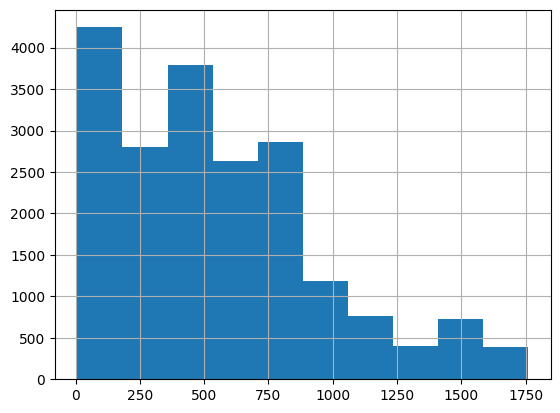

In [ ]:
# Check if the distribution is skew in numerical variable
transaction_df['standard_cost'].hist()
# Right skew, could use median to fill in missing value

In [ ]:
# Using median to fill in missing values
# # Inspect missing values in the dataset
# print(transaction_df.isnull().values.sum())
# # Impute the missing values with median imputation
# transaction_df[["standard_cost"]] = transaction_df[["standard_cost"]].fillna(transaction_df[["standard_cost"]].median())
# # Count the number of NaNs in the dataset to verify
# print(transaction_df.isnull().values.sum())

In [ ]:
# Using regression to fill in missing values
from sklearn.linear_model import LinearRegression
train_data = transaction_df.dropna(subset=['standard_cost'])
missing_data = transaction_df[transaction_df['standard_cost'].isnull()]
model = LinearRegression()
model.fit(train_data[['list_price']], train_data['standard_cost'])
predicted_costs = model.predict(missing_data[['list_price']])
transaction_df.loc[transaction_df['standard_cost'].isnull(), 'standard_cost'] = predicted_costs
transaction_df

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
1,1,2,2950,2017-02-25 00:00:00,False,Approved,Solex,Standard,medium,medium,71.49,53.62,41245
2,2,3,3120,2017-05-21 00:00:00,True,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701
3,3,37,402,2017-10-16 00:00:00,False,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82,36361
4,4,88,3135,2017-08-31 00:00:00,False,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.1,36145
5,5,78,787,2017-10-01 00:00:00,True,Approved,Giant Bicycles,Standard,medium,large,1765.3,709.48,42226
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,19996,51,1018,2017-06-24 00:00:00,True,Approved,OHM Cycles,Standard,high,medium,2005.66,1203.4,37823
19997,19997,41,127,2017-11-09 00:00:00,True,Approved,Solex,Road,medium,medium,416.98,312.74,35560
19998,19998,87,2284,2017-04-14 00:00:00,True,Approved,OHM Cycles,Standard,medium,medium,1636.9,44.71,40410
19999,19999,6,2764,2017-07-03 00:00:00,False,Approved,OHM Cycles,Standard,high,medium,227.88,136.73,38216


In [ ]:
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 1 to 20000
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   transaction_id           20000 non-null  object
 1   product_id               20000 non-null  object
 2   customer_id              20000 non-null  object
 3   transaction_date         20000 non-null  object
 4   online_order             19640 non-null  object
 5   order_status             20000 non-null  object
 6   brand                    19803 non-null  object
 7   product_line             19803 non-null  object
 8   product_class            19803 non-null  object
 9   product_size             19803 non-null  object
 10  list_price               20000 non-null  object
 11  standard_cost            20000 non-null  object
 12  product_first_sold_date  19803 non-null  object
dtypes: object(13)
memory usage: 2.0+ MB


## Fill in missing value for categorical variables

In [ ]:
 # group by -> count
transaction_df['product_line'].value_counts()

,count
product_line,
Standard,14176
Road,3970
Touring,1234
Mountain,423


In [ ]:
transaction_df['product_line'].value_counts().index[0]

'Standard'

In [ ]:
for col in transaction_df.columns:
    # Check if the column is of object type
    if transaction_df[col].dtypes == 'object':
        # Impute with the most frequent value
        transaction_df[col] = transaction_df[col].fillna(transaction_df[col].value_counts().index[0])
# Count the number of NaNs in the dataset and print the counts to verify
print(transaction_df.isnull().values.sum())

0


<ipython-input-24-0ff26b7e3a8b>:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  transaction_df[col] = transaction_df[col].fillna(transaction_df[col].value_counts().index[0])
<ipython-input-24-0ff26b7e3a8b>:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  transaction_df[col] = transaction_df[col].fillna(transaction_df[col].value_counts().index[0])
<ipython-input-24-0ff26b7e3a8b>:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To 

In [ ]:
# Fill in all missing values
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 1 to 20000
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_id           20000 non-null  int64         
 1   product_id               20000 non-null  int64         
 2   customer_id              20000 non-null  int64         
 3   transaction_date         20000 non-null  datetime64[ns]
 4   online_order             20000 non-null  bool          
 5   order_status             20000 non-null  object        
 6   brand                    20000 non-null  object        
 7   product_line             20000 non-null  object        
 8   product_class            20000 non-null  object        
 9   product_size             20000 non-null  object        
 10  list_price               20000 non-null  float64       
 11  standard_cost            20000 non-null  float64       
 12  product_first_sold_date  20000 n

## For customer demographic dataset

## Fill in missing value for numerical variables

In [ ]:
customerdemographic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   customer_id                          4000 non-null   int64  
 1   name                                 4000 non-null   object 
 2   gender                               4000 non-null   object 
 3   past_3_years_bike_related_purchases  4000 non-null   int64  
 4   DOB                                  3913 non-null   object 
 5   age                                  3999 non-null   float64
 6   job_title                            3494 non-null   object 
 7   job_industry_category                3344 non-null   object 
 8   wealth_segment                       4000 non-null   object 
 9   deceased_indicator                   4000 non-null   object 
 10  owns_car                             4000 non-null   object 
 11  tenure                        

<Axes: >

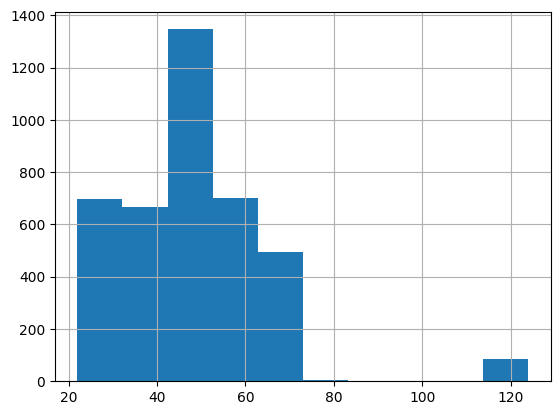

In [ ]:
# Check if the distribution is skew in numerical variable
customerdemographic_df['age'].hist()
# not skew, fill in missing value with mean

<Axes: >

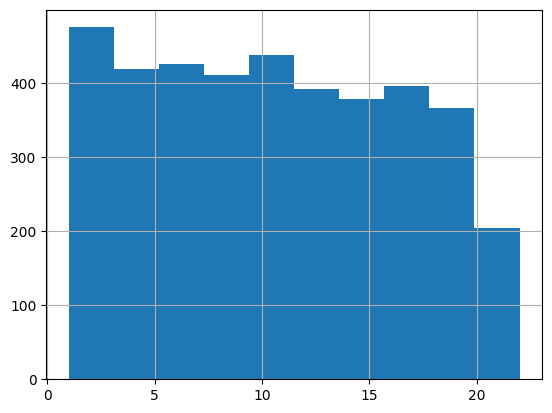

In [ ]:
# Check if the distribution is skew in numerical variable
customerdemographic_df['tenure'].hist()
# not skew, fill in missing value with mean

In [ ]:
# Inspect missing values in the dataset
print(customerdemographic_df.isnull().values.sum())
# Replace age of 124 to null value
new_age = customerdemographic_df[["age"]].replace(124.0, np.NaN)
customerdemographic_df[["age"]] = new_age
# Impute the missing values with mean imputation
customerdemographic_df[["age"]] = customerdemographic_df[["age"]].fillna(customerdemographic_df[["age"]].mean())
customerdemographic_df[["tenure"]] = customerdemographic_df[["tenure"]].fillna(customerdemographic_df[["tenure"]].mean())
# Count the number of NaNs in the dataset to verify
print(customerdemographic_df.isnull().values.sum())

1337
1249


In [ ]:
customerdemographic_df[["age"]]

,age
0,46.262526
1,46.262526
2,46.262526
3,46.262526
4,46.262526
...,...
3995,22.000000
3996,22.000000
3997,22.000000
3998,22.000000


In [ ]:
customerdemographic_df[["tenure"]]

,tenure
0,20.000000
1,10.657041
2,10.657041
3,10.657041
4,10.657041
...,...
3995,1.000000
3996,1.000000
3997,1.000000
3998,1.000000


In [ ]:
customerdemographic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   customer_id                          4000 non-null   int64  
 1   name                                 4000 non-null   object 
 2   gender                               4000 non-null   object 
 3   past_3_years_bike_related_purchases  4000 non-null   int64  
 4   DOB                                  3913 non-null   object 
 5   age                                  4000 non-null   float64
 6   job_title                            3494 non-null   object 
 7   job_industry_category                3344 non-null   object 
 8   wealth_segment                       4000 non-null   object 
 9   deceased_indicator                   4000 non-null   object 
 10  owns_car                             4000 non-null   object 
 11  tenure                        

## Fill in missing value for categorical variables

In [ ]:
 # group by -> count
customerdemographic_df['job_industry_category'].value_counts()

,count
job_industry_category,
Manufacturing,799
Financial Services,774
Health,602
Retail,358
Property,267
IT,223
Entertainment,136
Agriculture,113
Telecommunications,72


In [ ]:
customerdemographic_df['job_industry_category'].value_counts().index[0]

'Manufacturing'

In [ ]:
# replace unknown gender to null value (fill in missing value later)
new_gender = customerdemographic_df[["gender"]].replace('U',np.NaN)
customerdemographic_df[["gender"]] = new_gender
customerdemographic_df

,customer_id,name,gender,past_3_years_bike_related_purchases,DOB,age,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure
0,34,Jephthah Bachmann,NaN,59,1843-12-21,46.262526,Legal Assistant,IT,Affluent Customer,N,No,20.000000
1,144,Jory Barrabeale,NaN,71,NaN,46.262526,Environmental Tech,IT,Mass Customer,N,No,10.657041
2,168,Reggie Broggetti,NaN,8,NaN,46.262526,General Manager,IT,Affluent Customer,N,Yes,10.657041
3,267,Edgar Buckler,NaN,53,NaN,46.262526,NaN,IT,High Net Worth,N,No,10.657041
4,290,Giorgio Kevane,NaN,42,NaN,46.262526,Senior Sales Associate,IT,Mass Customer,N,No,10.657041
...,...,...,...,...,...,...,...,...,...,...,...,...
3995,2858,Benedicto Radki,Male,4,2002-01-09 00:00:00,22.000000,Recruiting Manager,NaN,Mass Customer,N,Yes,1.000000
3996,3173,Angelo,Male,55,2001-10-10 00:00:00,22.000000,Computer Systems Analyst I,Health,Mass Customer,N,Yes,1.000000
3997,3435,Stevena Allcock,Female,80,2002-01-15 00:00:00,22.000000,Senior Editor,NaN,Affluent Customer,N,No,1.000000
3998,3949,Costa Sleightholm,Male,24,2001-12-19 00:00:00,22.000000,Web Designer IV,Manufacturing,High Net Worth,N,Yes,1.000000


In [ ]:
for col in customerdemographic_df.columns:
    # Check if the column is of object type
    if customerdemographic_df[col].dtypes == 'object':
        # Impute with the most frequent value
       customerdemographic_df[col] = customerdemographic_df[col].fillna(customerdemographic_df[col].value_counts().index[0])
# Count the number of NaNs in the dataset and print the counts to verify
print(customerdemographic_df.isnull().values.sum())

0


In [ ]:
# Fill in all missing values
print(customerdemographic_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   customer_id                          4000 non-null   int64  
 1   name                                 4000 non-null   object 
 2   gender                               4000 non-null   object 
 3   past_3_years_bike_related_purchases  4000 non-null   int64  
 4   DOB                                  4000 non-null   object 
 5   age                                  4000 non-null   float64
 6   job_title                            4000 non-null   object 
 7   job_industry_category                4000 non-null   object 
 8   wealth_segment                       4000 non-null   object 
 9   deceased_indicator                   4000 non-null   object 
 10  owns_car                             4000 non-null   object 
 11  tenure                        

## For customer address dataset

In [ ]:
# replace 'New South Wales' to 'NSW' and 'Victoria' to 'VIC'
new_state1 = customeraddress_df[["state"]].replace('New South Wales','NSW')
customeraddress_df[["state"]] = new_state1
new_state2 = customeraddress_df[["state"]].replace('Victoria','VIC')
customeraddress_df[["state"]] = new_state2
customeraddress_df

,customer_id,address,postcode,state,country,property_valuation
1,1,060 Morning Avenue,2016,NSW,Australia,10
2,2,6 Meadow Vale Court,2153,NSW,Australia,10
3,4,0 Holy Cross Court,4211,QLD,Australia,9
4,5,17979 Del Mar Point,2448,NSW,Australia,4
5,6,9 Oakridge Court,3216,VIC,Australia,9
...,...,...,...,...,...,...
3995,3999,1482 Hauk Trail,3064,VIC,Australia,3
3996,4000,57042 Village Green Point,4511,QLD,Australia,6
3997,4001,87 Crescent Oaks Alley,2756,NSW,Australia,10
3998,4002,8194 Lien Street,4032,QLD,Australia,7


In [ ]:
customeraddress_df.info()
# There is no missing value to fill in

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 1 to 3999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         3999 non-null   object
 1   address             3999 non-null   object
 2   postcode            3999 non-null   object
 3   state               3999 non-null   object
 4   country             3999 non-null   object
 5   property_valuation  3999 non-null   object
dtypes: object(6)
memory usage: 187.6+ KB


# Bonus point 3: EDA - Transaction table merge customer table - dist - strip - rel - heatmap......

In [ ]:
# merge transactions table, customerdemographic table & cutomeraddress table
merge1 = pd.merge(transaction_df, customerdemographic_df, how="left", on="customer_id")
merge2 = pd.merge(merge1, customeraddress_df, how="left", on="customer_id")
merge2

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,...,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,address,postcode,state,country,property_valuation
0,1,2,2950,2017-02-25,False,Approved,Solex,Standard,medium,medium,...,Financial Services,Mass Customer,N,Yes,10.0,984 Hoepker Court,3064,VIC,Australia,6
1,2,3,3120,2017-05-21,True,Approved,Trek Bicycles,Standard,medium,large,...,Health,Mass Customer,N,Yes,10.0,4 Shopko Circle,2196,NSW,Australia,5
2,3,37,402,2017-10-16,False,Approved,OHM Cycles,Standard,low,medium,...,Retail,Affluent Customer,N,No,22.0,586 Miller Parkway,2835,NSW,Australia,1
3,4,88,3135,2017-08-31,False,Approved,Norco Bicycles,Standard,medium,medium,...,Financial Services,Mass Customer,N,No,16.0,1617 Harper Parkway,2096,NSW,Australia,10
4,5,78,787,2017-10-01,True,Approved,Giant Bicycles,Standard,medium,large,...,Retail,Affluent Customer,N,Yes,2.0,0601 Stephen Place,2292,NSW,Australia,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,51,1018,2017-06-24,True,Approved,OHM Cycles,Standard,high,medium,...,Manufacturing,Mass Customer,N,Yes,7.0,3 Hayes Court,3109,VIC,Australia,10
19996,19997,41,127,2017-11-09,True,Approved,Solex,Road,medium,medium,...,Financial Services,Mass Customer,N,No,19.0,0 Pearson Crossing,4405,QLD,Australia,1
19997,19998,87,2284,2017-04-14,True,Approved,OHM Cycles,Standard,medium,medium,...,Telecommunications,High Net Worth,N,No,14.0,10055 Old Shore Lane,3630,VIC,Australia,1
19998,19999,6,2764,2017-07-03,False,Approved,OHM Cycles,Standard,high,medium,...,Financial Services,Mass Customer,N,Yes,20.0,1 Wayridge Park,4301,QLD,Australia,1


<ipython-input-41-75f7612a7099>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merge2['profit'], bins=40, hist=True, kde=True, rug=True, fit=None, color='g', vertical=False)


<Axes: xlabel='profit', ylabel='Density'>

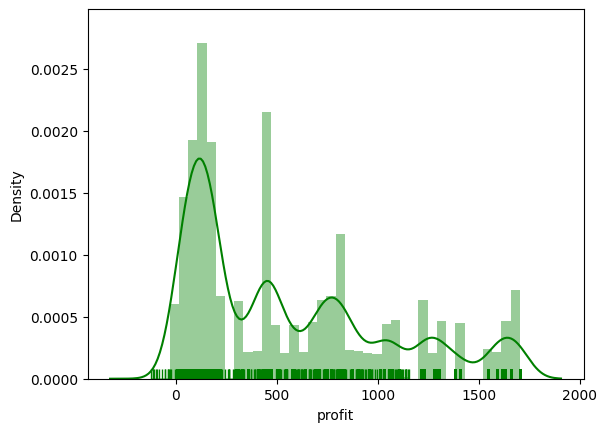

In [ ]:
# distribution of numerical variable in the above dataset
# profit = list_price - standard_cost
merge2['profit'] = merge2['list_price'] - merge2['standard_cost']
sns.distplot(merge2['profit'], bins=40, hist=True, kde=True, rug=True, fit=None, color='g', vertical=False)
# right skew

<ipython-input-42-dfa96bd71181>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merge2['past_3_years_bike_related_purchases'], bins=40, hist=True, kde=True, rug=True, fit=None, color='g', vertical=False)


<Axes: xlabel='past_3_years_bike_related_purchases', ylabel='Density'>

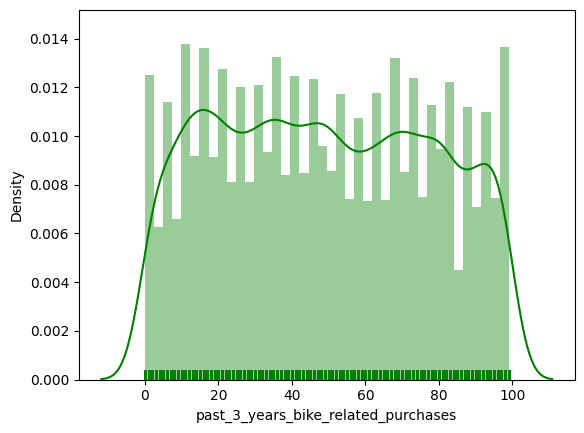

In [ ]:
# past_3_years_bike_related_purchases
sns.distplot(merge2['past_3_years_bike_related_purchases'], bins=40, hist=True, kde=True, rug=True, fit=None, color='g', vertical=False)

<ipython-input-43-53bf419c6903>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merge2['age'], bins=40, hist=True, kde=True, rug=True, fit=None, color='g', vertical=False)


<Axes: xlabel='age', ylabel='Density'>

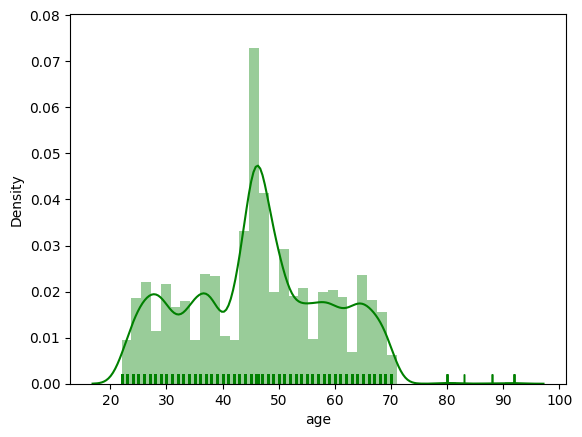

In [ ]:
# age
sns.distplot(merge2['age'], bins=40, hist=True, kde=True, rug=True, fit=None, color='g', vertical=False)

<ipython-input-44-816403f410b4>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merge2['tenure'], bins=40, hist=True, kde=True, rug=True, fit=None, color='g', vertical=False)


<Axes: xlabel='tenure', ylabel='Density'>

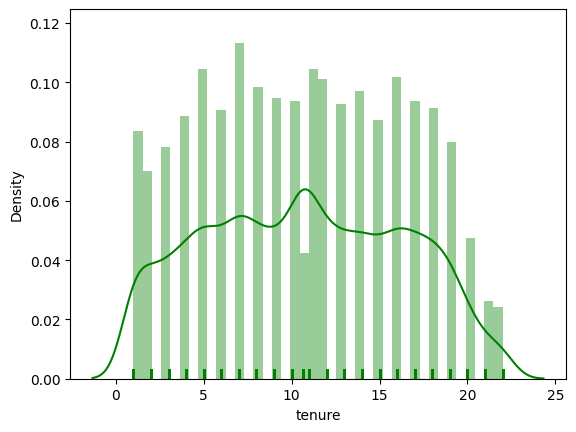

In [ ]:
# tenure
sns.distplot(merge2['tenure'], bins=40, hist=True, kde=True, rug=True, fit=None, color='g', vertical=False)

## Stripplot

### relationship between numerical and categorical

<ipython-input-45-d955824aeeee>:4: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(x='job_industry_category', y='profit', hue='gender', data=merge2,


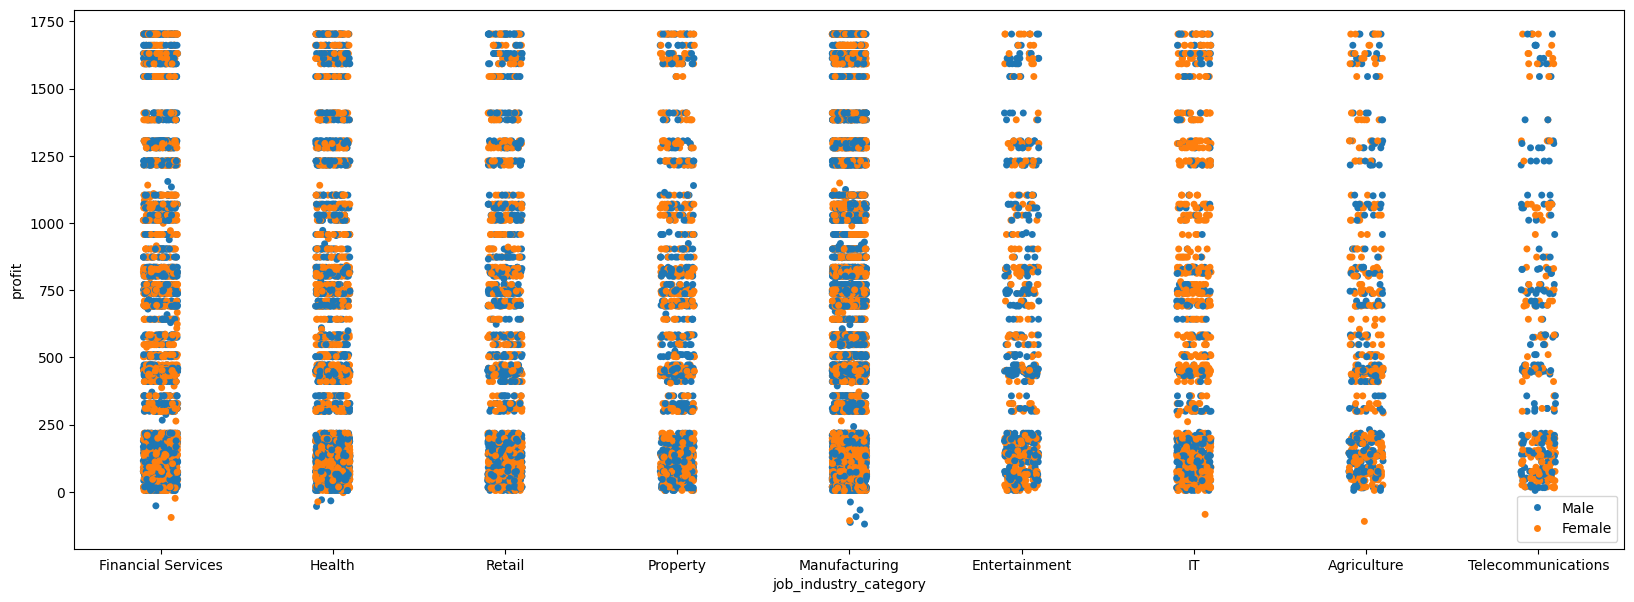

In [ ]:
# three dimensions
# job_industry_category vs. gender vs. profit
plt.figure(figsize=(20, 7))
sns.stripplot(x='job_industry_category', y='profit', hue='gender', data=merge2,
                      color=None, palette=None, size=5,
                      edgecolor="gray", linewidth=0,
                      ax=None)
plt.legend(loc='best')

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


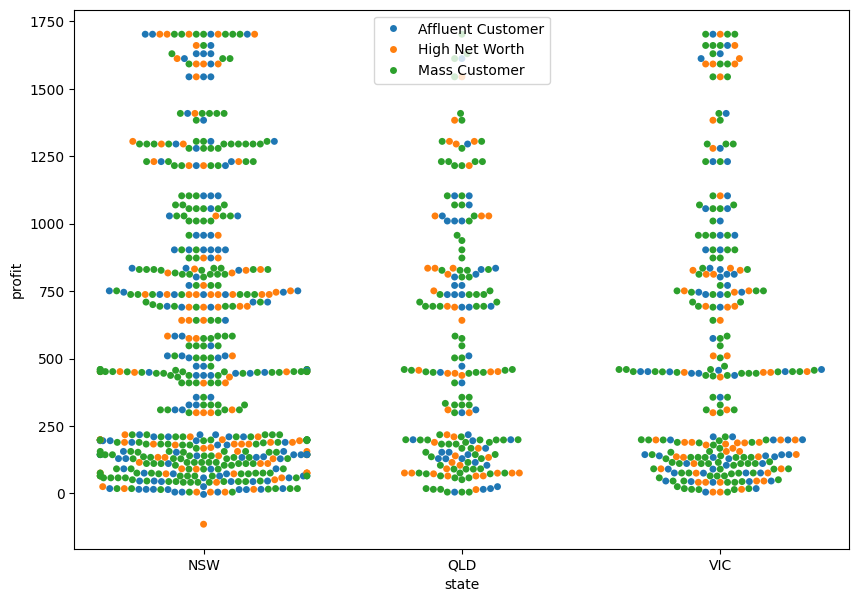

In [ ]:
# state vs. wealth_segment vs. profit
plt.figure(figsize=(10, 7))
sns.swarmplot(x='state', y='profit', hue='wealth_segment', data=merge2.sample(1000))
plt.legend(loc = 'best')

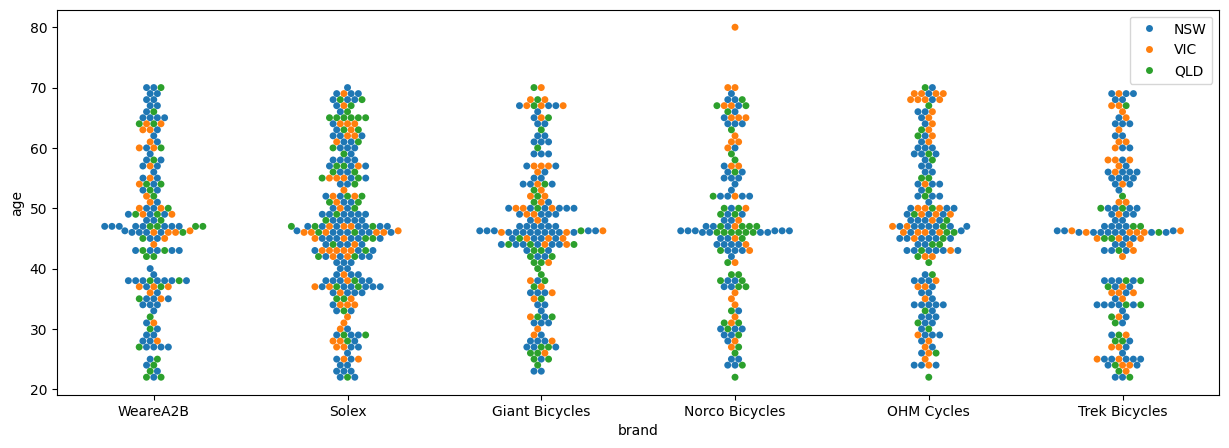

In [ ]:
# brand vs. state vs. age
plt.figure(figsize=(15, 5))
sns.swarmplot(x='brand', y='age', hue='state', data=merge2.sample(1000))
plt.legend(loc = 'best')

<Figure size 1500x700 with 0 Axes>

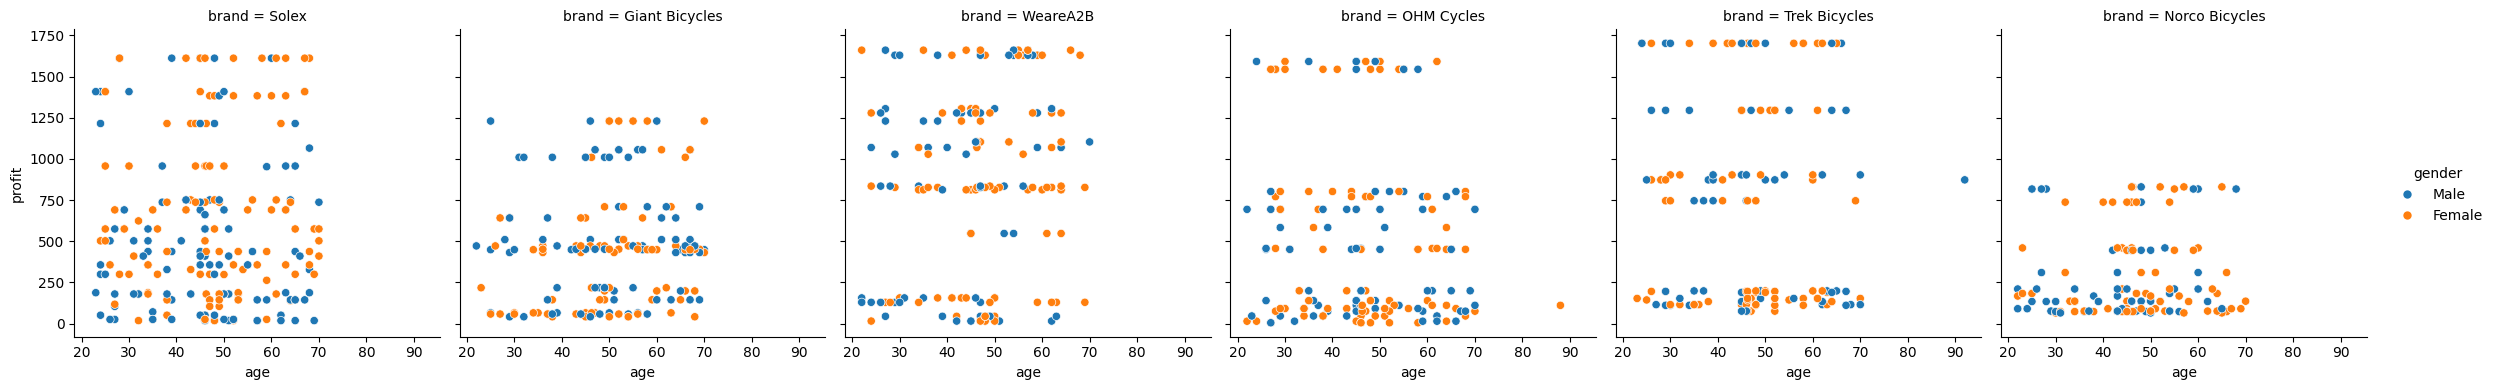

In [ ]:
# four dimensions
# relational plot
# age vs. profit vs. gender vs. brand
plt.figure(figsize=(15, 7))
sns.color_palette('pastel')
ax = sns.relplot(data=merge2.sample(1000), kind='scatter', x='age', y='profit', hue='gender', col='brand', height=4)
plt.show()

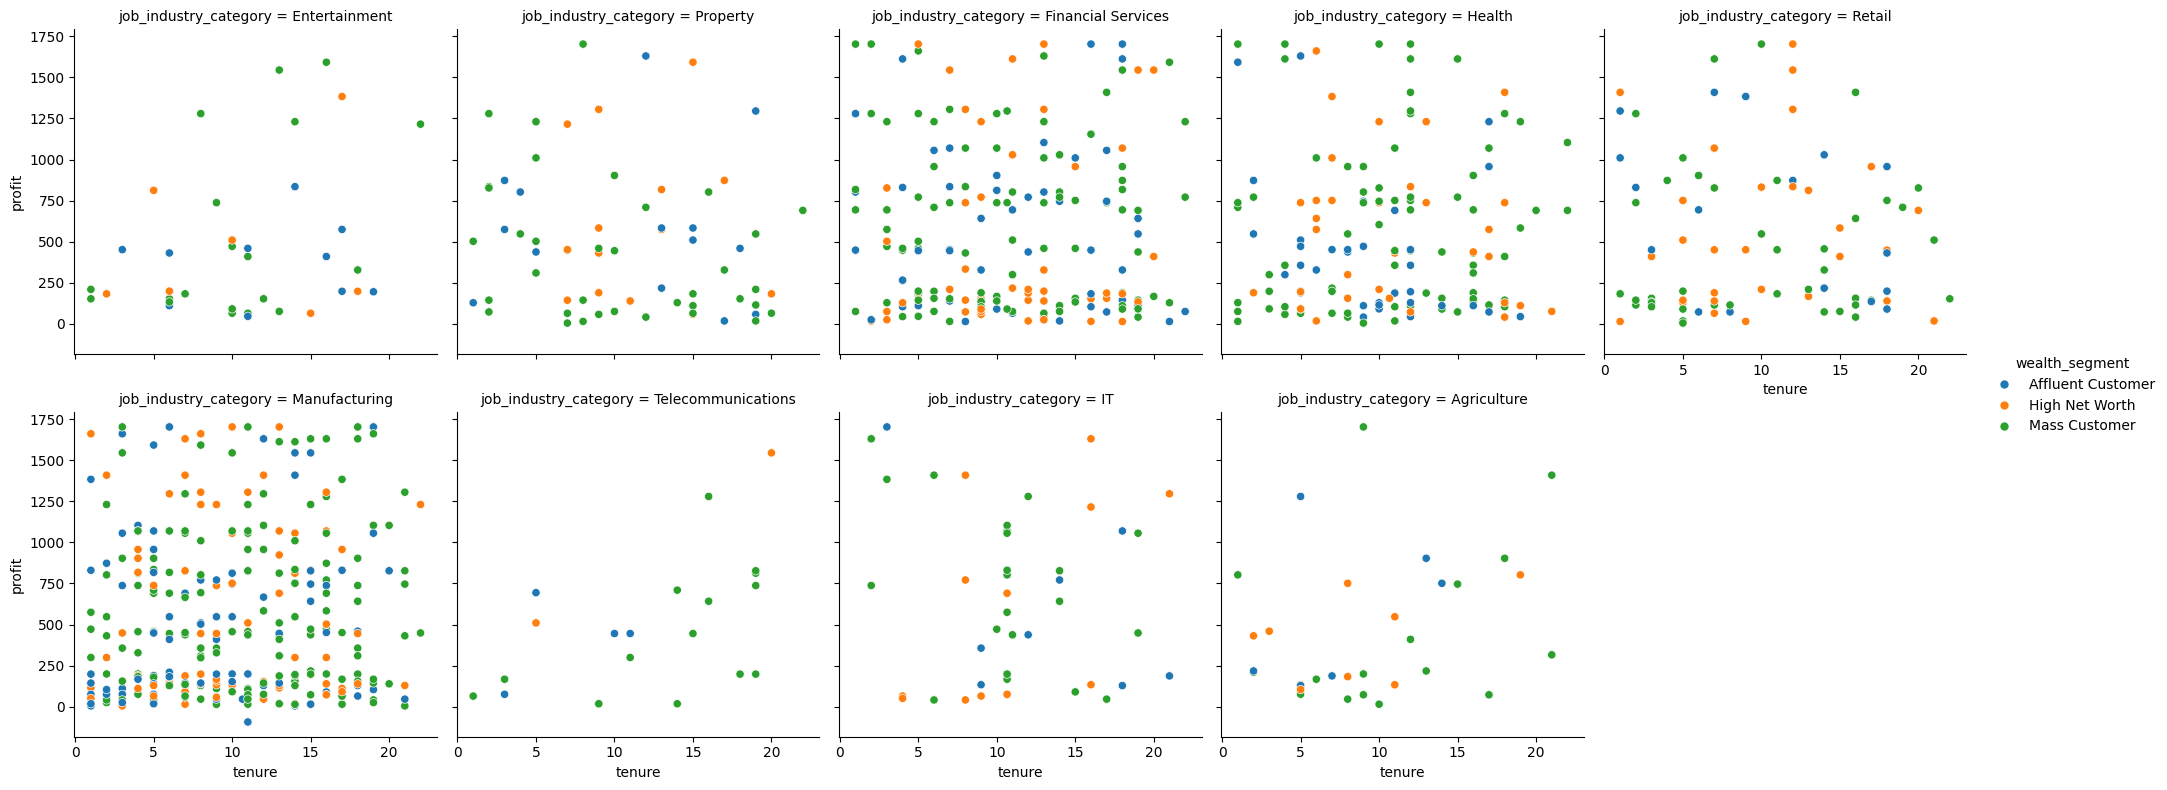

In [ ]:
# relational plot
# tenure vs. profit vs. wealth_segment vs. job_category_industry
sns.color_palette('pastel')
ax = sns.relplot(data=merge2.sample(1000), kind='scatter', x='tenure', y='profit', hue='wealth_segment', col='job_industry_category', height=4, col_wrap=5)
plt.show()

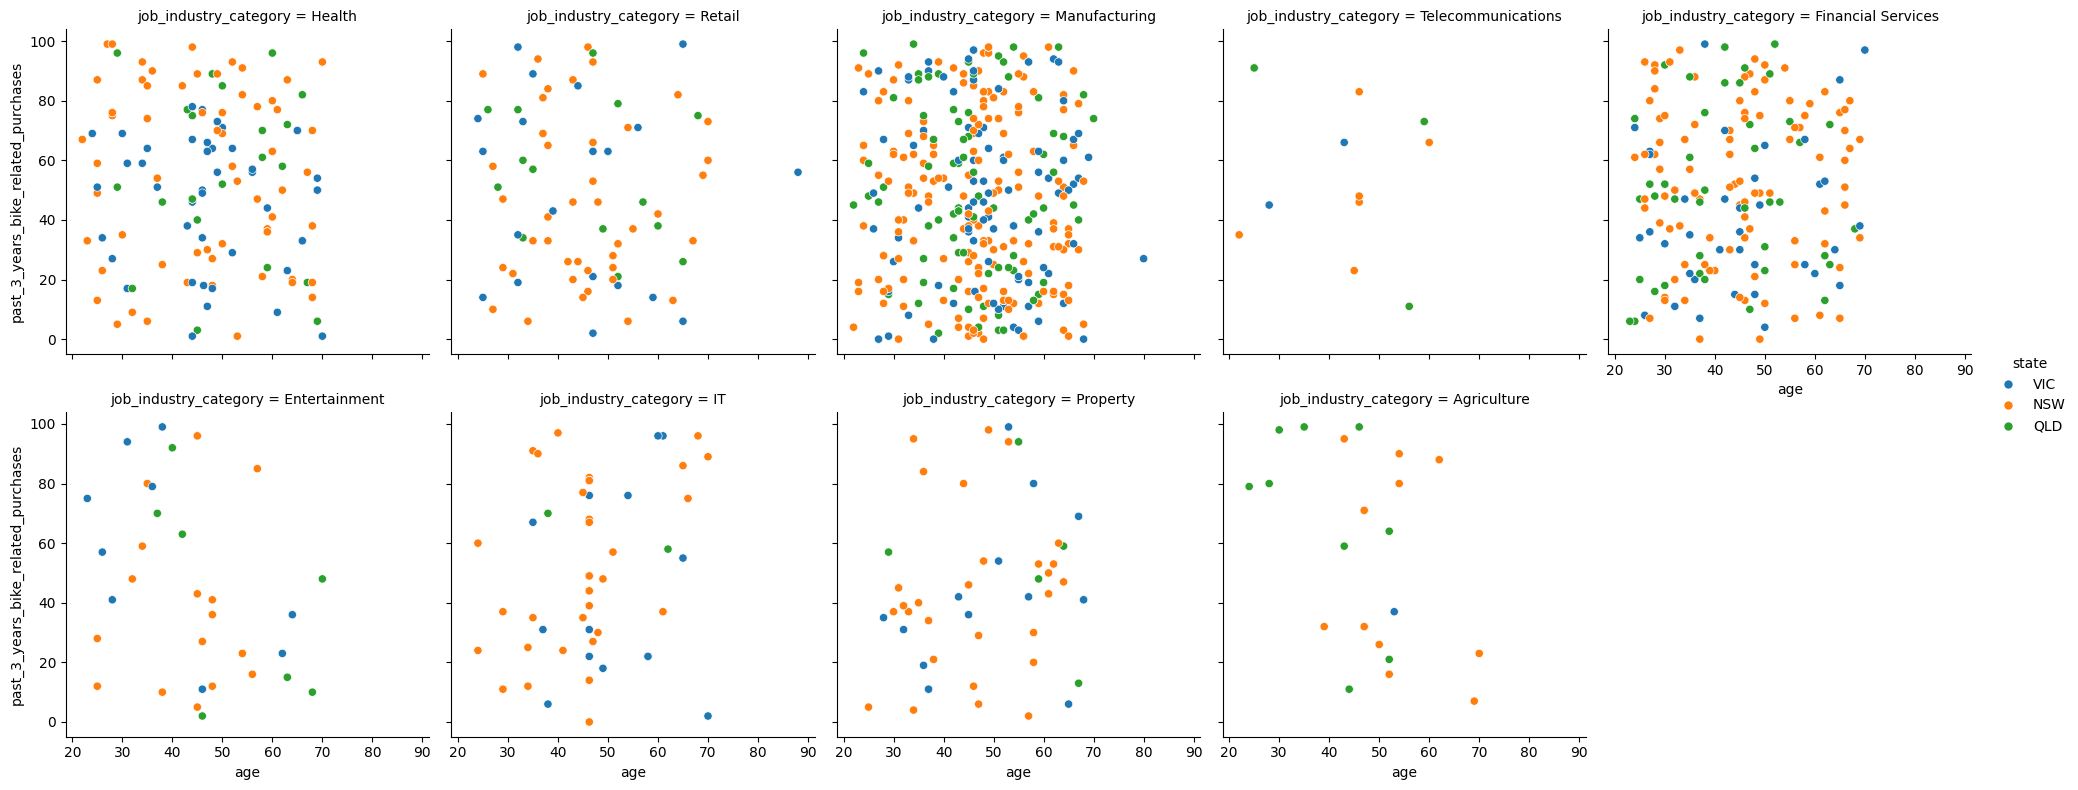

In [ ]:
# relational plot
# past_3_years_bike_related_purchases vs. age vs. state vs. job_category_industry
sns.color_palette('pastel')
ax = sns.relplot(data=merge2.sample(1000), kind='scatter', x='age', y='past_3_years_bike_related_purchases', hue='state', col='job_industry_category', height=4, col_wrap=5)
plt.show()

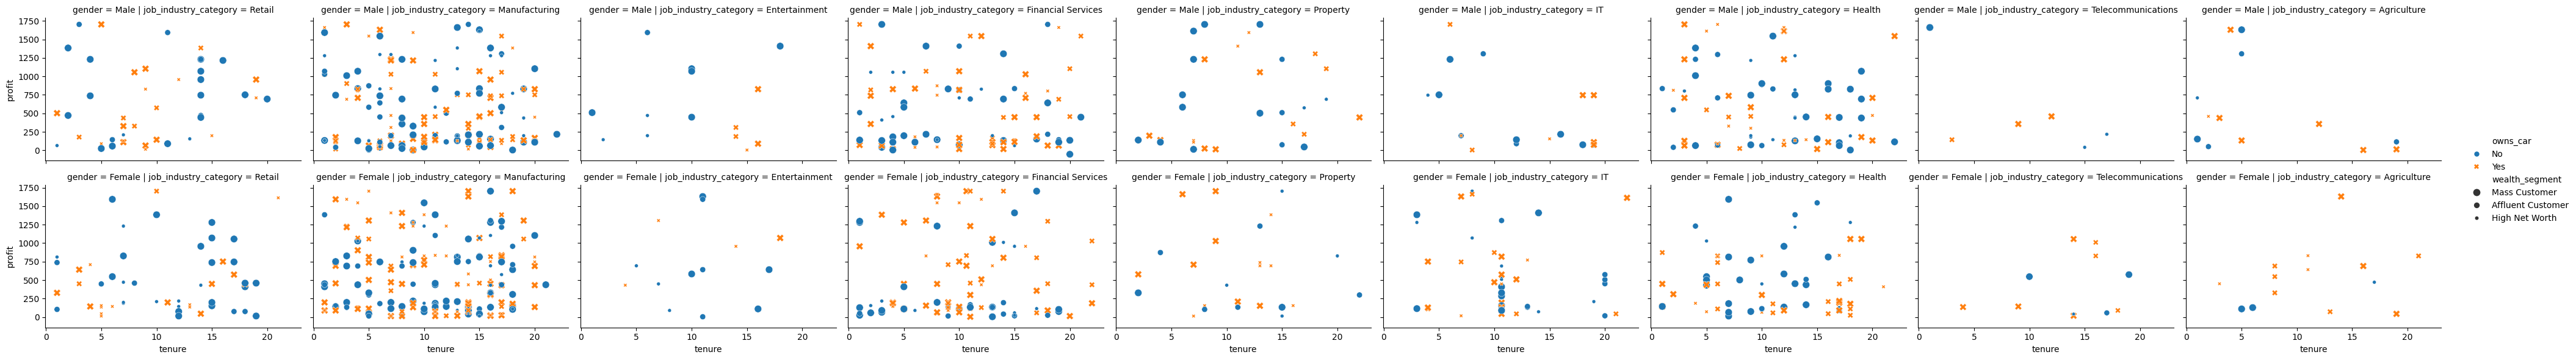

In [ ]:
# multi-dimensions
sns.color_palette('pastel')
ax = sns.relplot(data=merge2.sample(1000), kind='scatter', x='tenure',y='profit',hue='owns_car',col='job_industry_category', height=3, style='owns_car',
                 size='wealth_segment', row='gender', aspect=1.5)
plt.show()

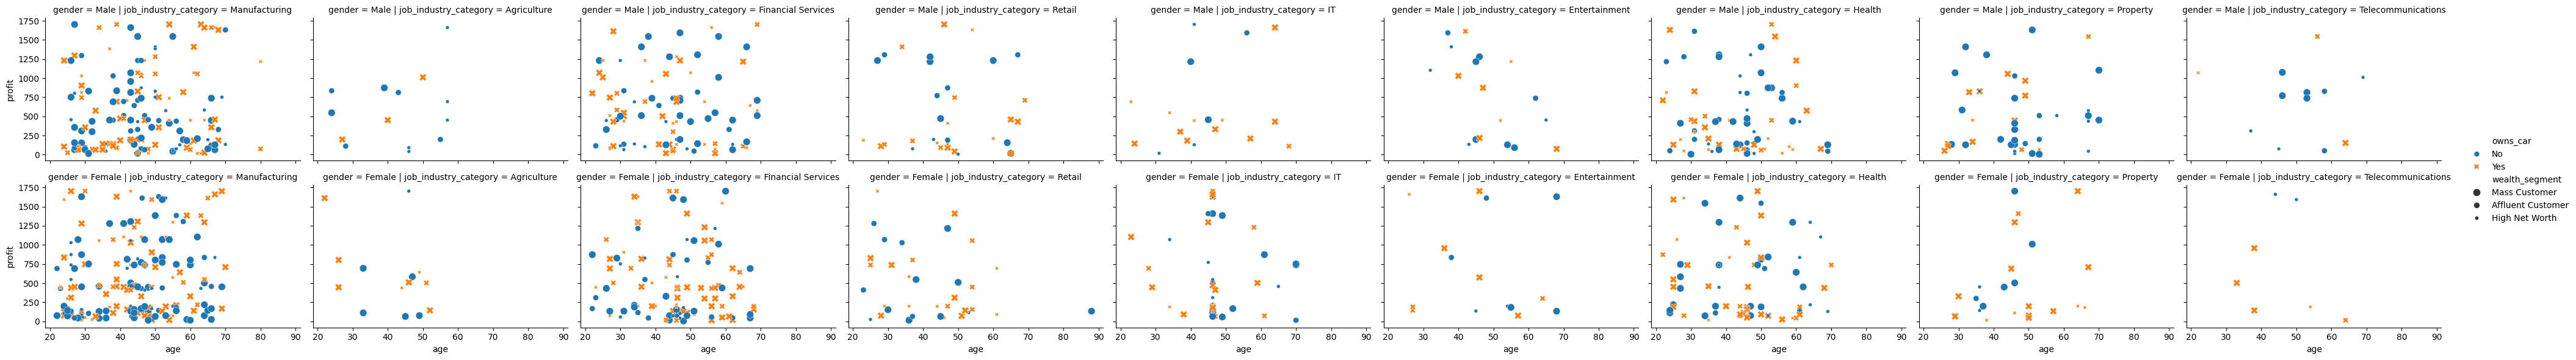

In [ ]:
sns.color_palette('pastel')
ax = sns.relplot(data=merge2.sample(1000), kind='scatter', x='age',y='profit',hue='owns_car',col='job_industry_category', height=3, style='owns_car',
                 size='wealth_segment', row='gender', aspect=1.5)
plt.show()

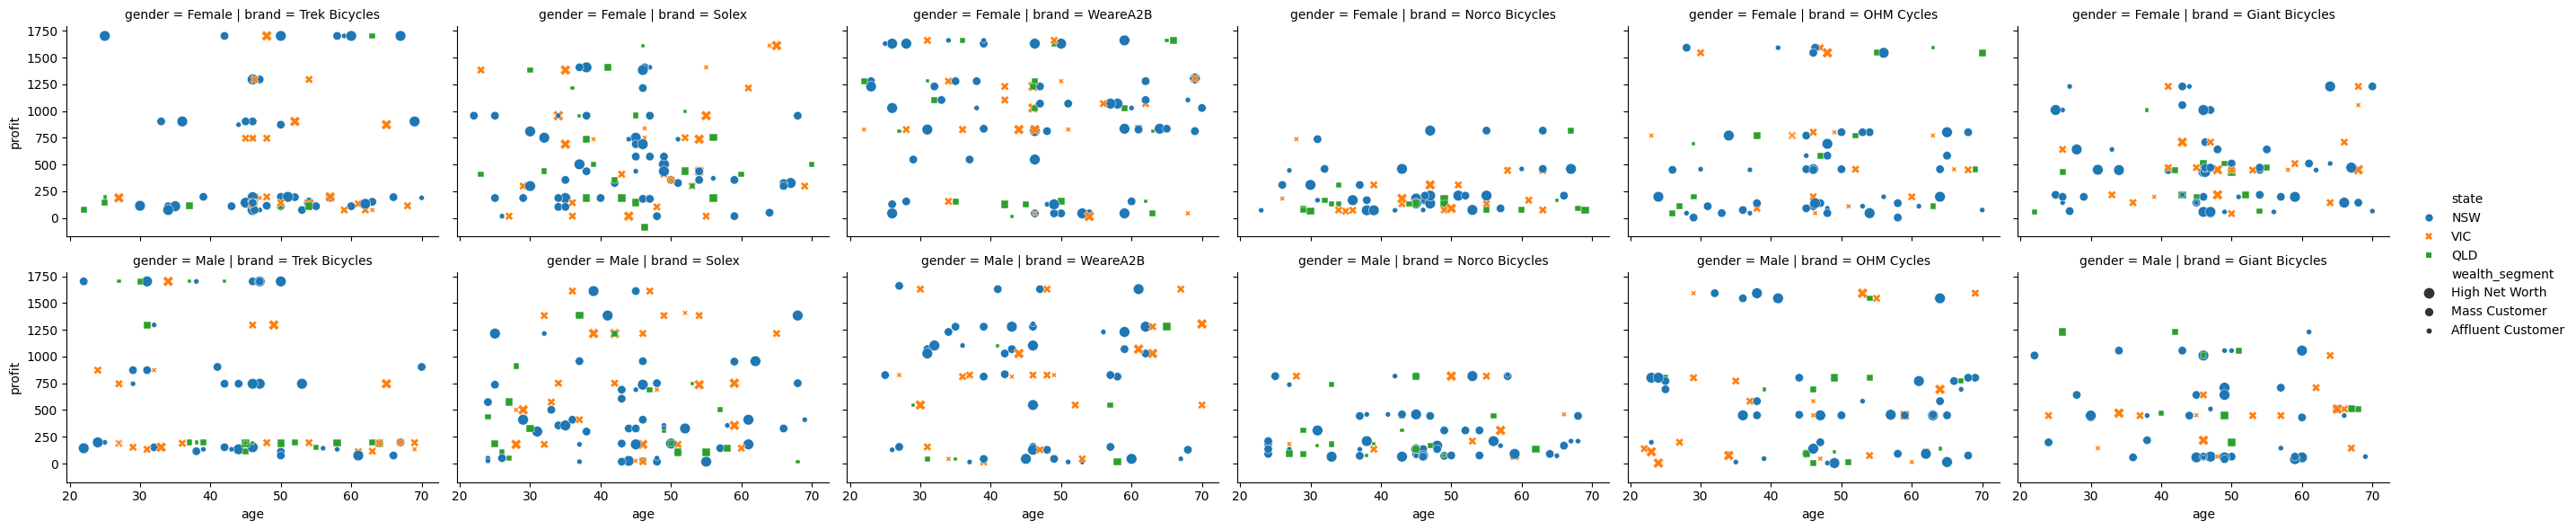

In [ ]:
sns.color_palette('pastel')
ax = sns.relplot(data=merge2.sample(1000), kind='scatter', x='age',y='profit',hue='state',col='brand', height=3, style='state',
                 size='wealth_segment', row='gender', aspect=1.5)
plt.show()

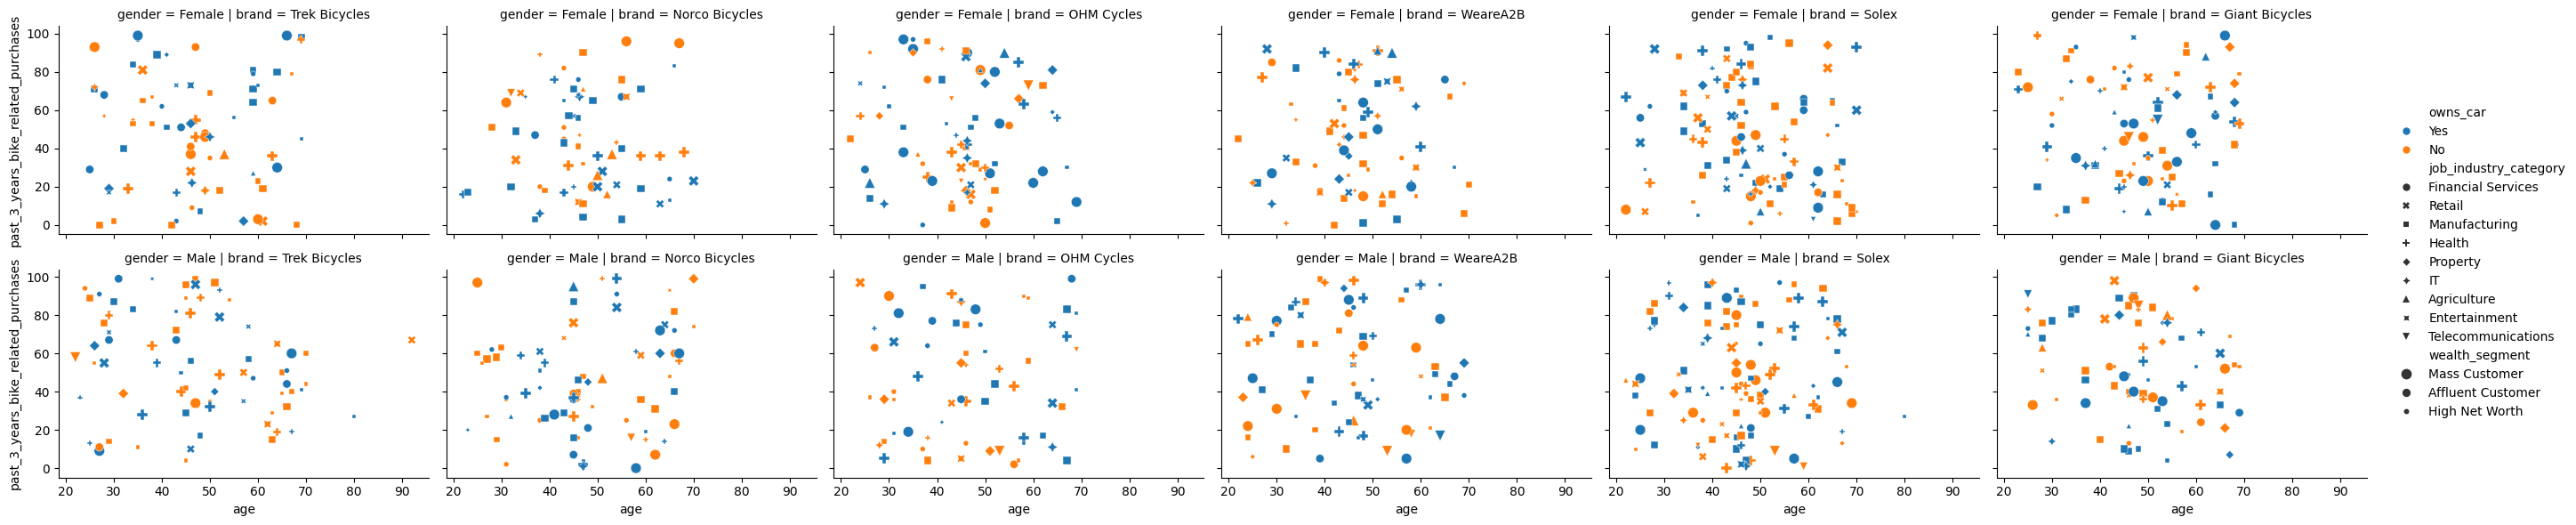

In [ ]:
sns.color_palette('pastel')
ax = sns.relplot(data=merge2.sample(1000), kind='scatter', x='age',y='past_3_years_bike_related_purchases',hue='owns_car',col='brand', height=3, style='job_industry_category',
                 size='wealth_segment', row='gender', aspect=1.5)
plt.show()

### relationship between numerical and numerical

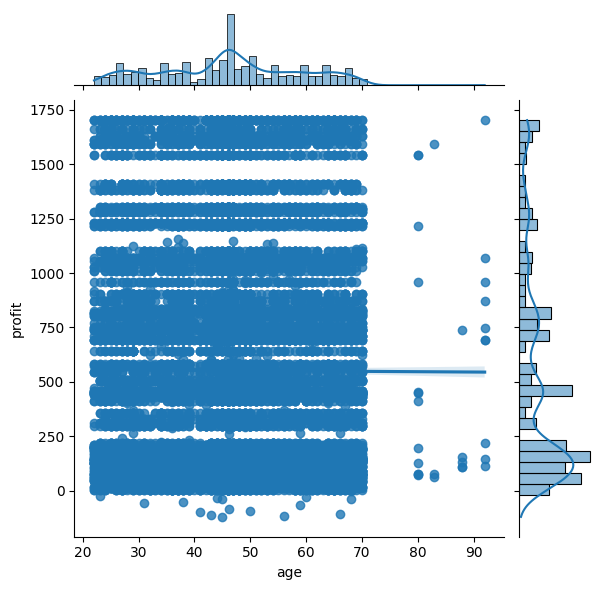

In [ ]:
# profit vs age
sns.jointplot(x='age', y='profit',
                      data=merge2,  kind="reg",
                      color=None, ratio=5,
                      dropna=True, xlim=None,
                      ylim=None)

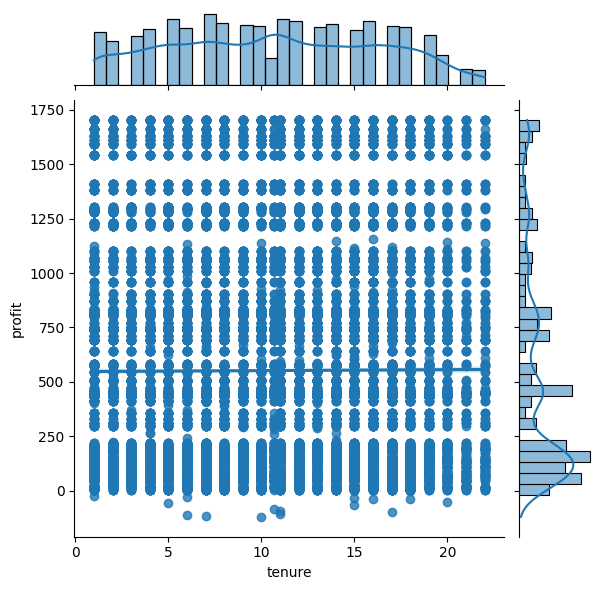

In [ ]:
# profit vs tenure
sns.jointplot(x='tenure', y='profit',
                      data=merge2,  kind="reg",
                      color=None, ratio=5,
                      dropna=True, xlim=None,
                      ylim=None)

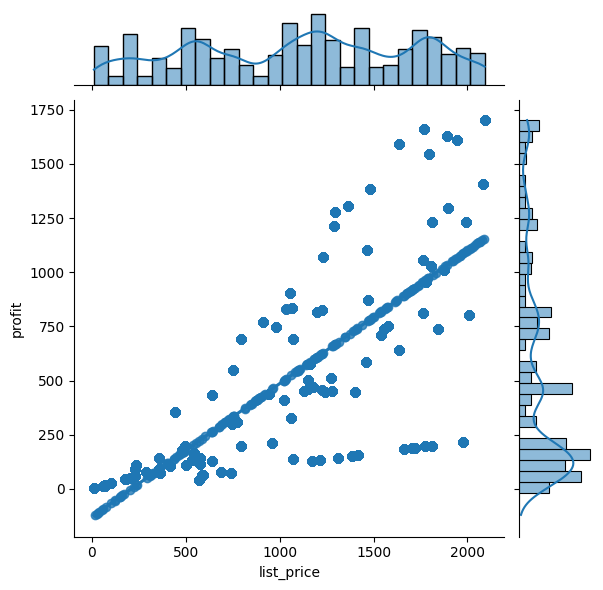

In [ ]:
# list_price vs profit
sns.jointplot(x='list_price', y='profit',
                      data=merge2,  kind="reg",
                      color=None, ratio=5,
                      dropna=True, xlim=None,
                      ylim=None)

<Axes: >

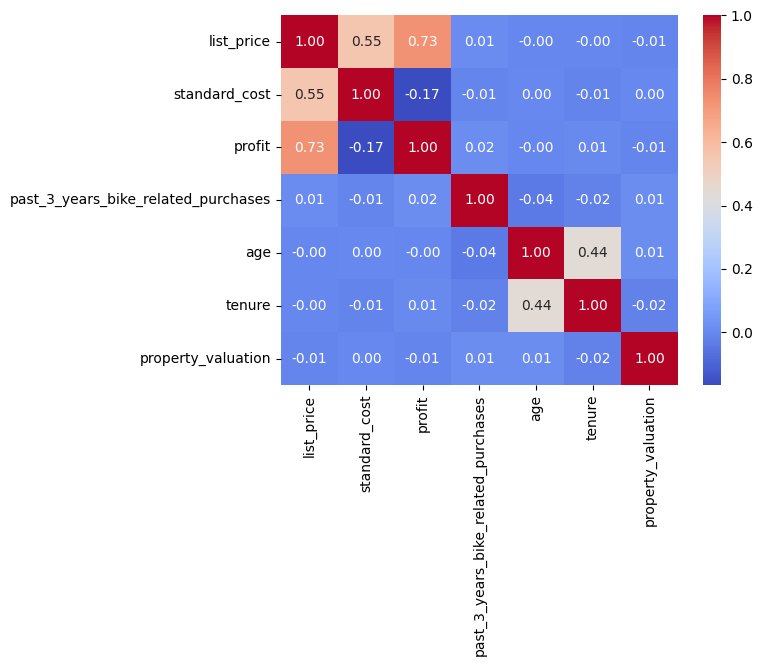

In [ ]:
# Heatmap
# correlation coefficients, strong/moderate/weak
# relation between multiple numerical variables
sns.heatmap(merge2[["list_price","standard_cost","profit","past_3_years_bike_related_purchases","age",'tenure','property_valuation']].corr(), annot=True, fmt=".2f", cmap = "coolwarm")

# Cohort Analysis

##Assigned the cohorts and calculated the monthly offset

In [ ]:
transaction_df

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
1,1,2,2950,2017-02-25,False,Approved,Solex,Standard,medium,medium,71.49,53.62,41245
2,2,3,3120,2017-05-21,True,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701
3,3,37,402,2017-10-16,False,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82,36361
4,4,88,3135,2017-08-31,False,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.10,36145
5,5,78,787,2017-10-01,True,Approved,Giant Bicycles,Standard,medium,large,1765.30,709.48,42226
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,19996,51,1018,2017-06-24,True,Approved,OHM Cycles,Standard,high,medium,2005.66,1203.40,37823
19997,19997,41,127,2017-11-09,True,Approved,Solex,Road,medium,medium,416.98,312.74,35560
19998,19998,87,2284,2017-04-14,True,Approved,OHM Cycles,Standard,medium,medium,1636.90,44.71,40410
19999,19999,6,2764,2017-07-03,False,Approved,OHM Cycles,Standard,high,medium,227.88,136.73,38216


In [ ]:
# transaction_date -> transaction_month
# A function that will parse the date Time based cohort:  1 day of month
def get_month(x):
  return dt.datetime(x.year, x.month, 1)
# Create transaction_date column based on month and store in TransactionMonth
transaction_df['TransactionMonth'] = transaction_df['transaction_date'].apply(get_month)
transaction_df

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,TransactionMonth
1,1,2,2950,2017-02-25,False,Approved,Solex,Standard,medium,medium,71.49,53.62,41245,2017-02-01
2,2,3,3120,2017-05-21,True,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701,2017-05-01
3,3,37,402,2017-10-16,False,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82,36361,2017-10-01
4,4,88,3135,2017-08-31,False,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.10,36145,2017-08-01
5,5,78,787,2017-10-01,True,Approved,Giant Bicycles,Standard,medium,large,1765.30,709.48,42226,2017-10-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,19996,51,1018,2017-06-24,True,Approved,OHM Cycles,Standard,high,medium,2005.66,1203.40,37823,2017-06-01
19997,19997,41,127,2017-11-09,True,Approved,Solex,Road,medium,medium,416.98,312.74,35560,2017-11-01
19998,19998,87,2284,2017-04-14,True,Approved,OHM Cycles,Standard,medium,medium,1636.90,44.71,40410,2017-04-01
19999,19999,6,2764,2017-07-03,False,Approved,OHM Cycles,Standard,high,medium,227.88,136.73,38216,2017-07-01


In [ ]:
# Every customer's cohort month:The earliest transaction month for each customer.
transaction_df['CohortMonth'] = transaction_df.groupby('customer_id')['TransactionMonth'].transform('min')
transaction_df

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,TransactionMonth,CohortMonth
1,1,2,2950,2017-02-25,False,Approved,Solex,Standard,medium,medium,71.49,53.62,41245,2017-02-01,2017-02-01
2,2,3,3120,2017-05-21,True,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701,2017-05-01,2017-01-01
3,3,37,402,2017-10-16,False,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82,36361,2017-10-01,2017-01-01
4,4,88,3135,2017-08-31,False,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.10,36145,2017-08-01,2017-02-01
5,5,78,787,2017-10-01,True,Approved,Giant Bicycles,Standard,medium,large,1765.30,709.48,42226,2017-10-01,2017-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,19996,51,1018,2017-06-24,True,Approved,OHM Cycles,Standard,high,medium,2005.66,1203.40,37823,2017-06-01,2017-01-01
19997,19997,41,127,2017-11-09,True,Approved,Solex,Road,medium,medium,416.98,312.74,35560,2017-11-01,2017-01-01
19998,19998,87,2284,2017-04-14,True,Approved,OHM Cycles,Standard,medium,medium,1636.90,44.71,40410,2017-04-01,2017-04-01
19999,19999,6,2764,2017-07-03,False,Approved,OHM Cycles,Standard,high,medium,227.88,136.73,38216,2017-07-01,2017-02-01


## Calculating time offset in Month as Cohort Index
Calculating the time offset for each transaction allows you to evaluate the metrics for each cohort in a comparable fashion.
First, we will create 6 variables that capture the integer value of years, months, and days for Transaction and Cohort Date using the get_date_int() function.

In [ ]:
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    day = df[column].dt.day
    return year, month, day
# Getting the integers for date parts from the `transaction_date` column
transcation_year, transaction_month, _ = get_date_int(transaction_df, 'TransactionMonth')
# Getting the integers for date parts from the `cohort_date` column
cohort_year, cohort_month, _ = get_date_int(transaction_df, 'CohortMonth')

In [ ]:
# Calculate difference in months
months_diff = transaction_month - cohort_month
""" Extract the difference in months from all previous values
 "+1" in addeded at the end so that first month is marked as 1 instead of 0 for easier interpretation.
 """
transaction_df['CohortIndex'] = months_diff  + 1
transaction_df.head(5)

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,TransactionMonth,CohortMonth,CohortIndex
1,1,2,2950,2017-02-25,False,Approved,Solex,Standard,medium,medium,71.49,53.62,41245,2017-02-01,2017-02-01,1
2,2,3,3120,2017-05-21,True,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701,2017-05-01,2017-01-01,5
3,3,37,402,2017-10-16,False,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82,36361,2017-10-01,2017-01-01,10
4,4,88,3135,2017-08-31,False,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.10,36145,2017-08-01,2017-02-01,7
5,5,78,787,2017-10-01,True,Approved,Giant Bicycles,Standard,medium,large,1765.30,709.48,42226,2017-10-01,2017-01-01,10


In [ ]:
# Counting daily active user from each cohort
# Counting number of unique customer id's falling in each group of CohortMonth and CohortIndex
cohort_data = transaction_df.groupby(['CohortMonth', 'CohortIndex']).nunique()['customer_id'].reset_index()
# Printing top 5 rows of Dataframe
cohort_data.head()

,CohortMonth,CohortIndex,customer_id
0,2017-01-01,1,1354
1,2017-01-01,2,486
2,2017-01-01,3,508
3,2017-01-01,4,509
4,2017-01-01,5,502


# Calculate business metrics: Retention rate

**The percentage of active customers compared to the total number of customers after a specific time interval is called retention rate.**
In this section, we will calculate the retention count for each cohort Month paired with cohort Index
Now that we have a count of the retained customers for each cohortMonth and cohortIndex. We will calculate the retention rate for each Cohort.
We will create a pivot table for this purpose.

In [ ]:
# transform cohort data into a pivot table
cohort_counts = cohort_data.pivot(index='CohortMonth',  columns ='CohortIndex', values = 'customer_id')
cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,
2017-01-01,1354.0,486.0,508.0,509.0,502.0,483.0,518.0,529.0,500.0,531.0,497.0,516.0
2017-02-01,800.0,325.0,298.0,313.0,288.0,298.0,308.0,281.0,329.0,308.0,296.0,NaN
2017-03-01,484.0,167.0,174.0,167.0,182.0,184.0,172.0,212.0,189.0,181.0,NaN,NaN
2017-04-01,336.0,111.0,121.0,153.0,143.0,121.0,142.0,126.0,132.0,NaN,NaN,NaN
2017-05-01,210.0,85.0,81.0,87.0,71.0,74.0,73.0,81.0,NaN,NaN,NaN,NaN
2017-06-01,122.0,45.0,44.0,47.0,46.0,46.0,53.0,NaN,NaN,NaN,NaN,NaN
2017-07-01,77.0,26.0,29.0,32.0,37.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-01,51.0,19.0,21.0,17.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,23.0,7.0,7.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Create retention rate table
cohort_sizes = cohort_counts.iloc[:,0] #第一个column
retention = cohort_counts.divide(cohort_sizes, axis=0)
retention_table = retention.round(3)*100 #convert into %
retention_table

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,
2017-01-01,100.0,35.9,37.5,37.6,37.1,35.7,38.3,39.1,36.9,39.2,36.7,38.1
2017-02-01,100.0,40.6,37.2,39.1,36.0,37.2,38.5,35.1,41.1,38.5,37.0,NaN
2017-03-01,100.0,34.5,36.0,34.5,37.6,38.0,35.5,43.8,39.0,37.4,NaN,NaN
2017-04-01,100.0,33.0,36.0,45.5,42.6,36.0,42.3,37.5,39.3,NaN,NaN,NaN
2017-05-01,100.0,40.5,38.6,41.4,33.8,35.2,34.8,38.6,NaN,NaN,NaN,NaN
2017-06-01,100.0,36.9,36.1,38.5,37.7,37.7,43.4,NaN,NaN,NaN,NaN,NaN
2017-07-01,100.0,33.8,37.7,41.6,48.1,31.2,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-01,100.0,37.3,41.2,33.3,25.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,100.0,30.4,30.4,39.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The retention rate dataframe represents Customer retained across Cohorts. We can read it as follows:

Index value represents the Cohort Columns represent the number of months since the current Cohort For instance: The value at CohortMonth 2017-01-01, CohortIndex 3 is 35.9 and represents 35.9% of customers from cohort 2017-01 were retained in the 3rd Month. Also, you can see from the retention Rate DataFrame:

*   Retention Rate 1st index i.e 1st month is 100% as all the customers for that particular customer signed up in 1st Month
*   The retention rate may increase or decrease in subsequent Indexes.
*   Values towards the bottom right have a lot of NaN values.



#Visualizing the retention rate
# Before we starting plotting our heatmap, let’s set the index of our Retention rate dataframe to a more readable string format.

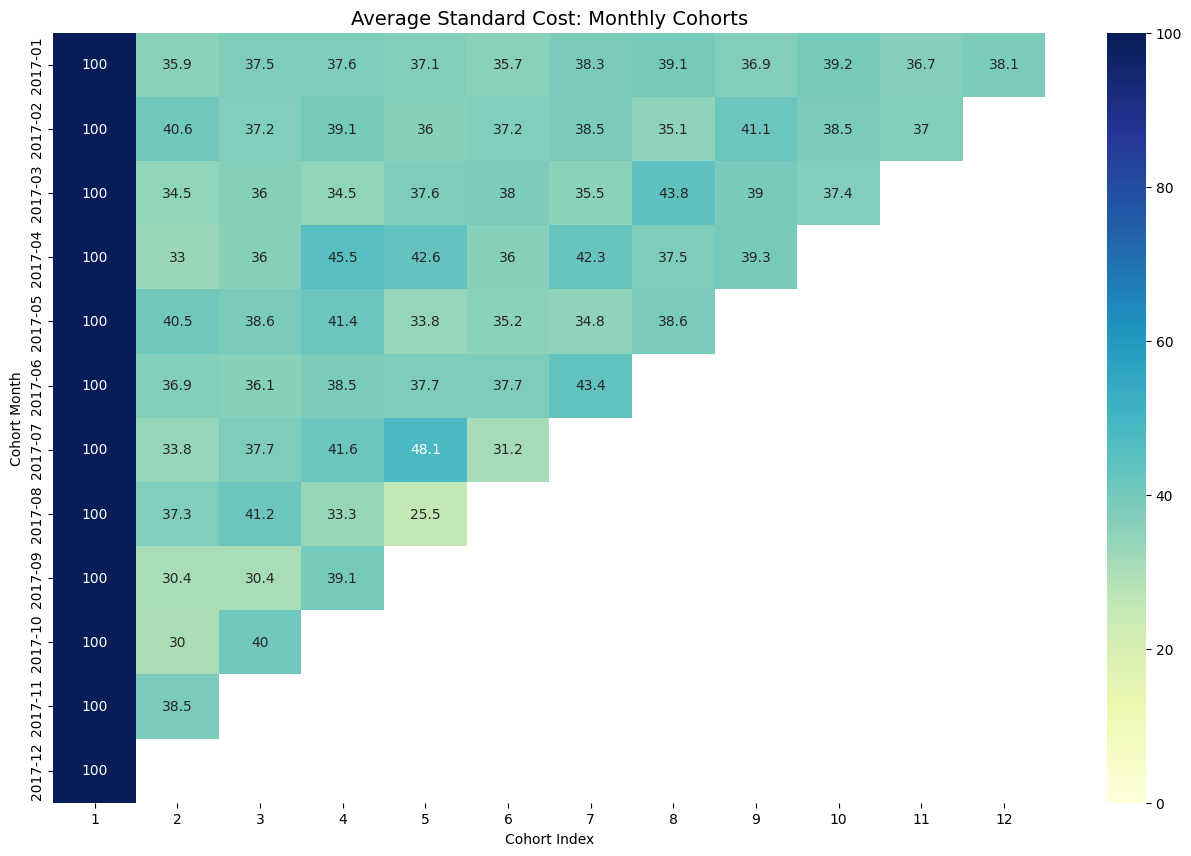

In [ ]:
retention_table.index = retention_table.index.strftime('%Y-%m') # format index of retention table into year-month
# Initialize the figure
plt.figure(figsize=(16, 10))
# Adding a title
plt.title('Average Standard Cost: Monthly Cohorts', fontsize = 14)
# Creating the heatmap
sns.heatmap(retention_table, annot = True,vmin = 0.0, vmax =100,cmap="YlGnBu", fmt='g')
plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index')
#plt.yticks( rotation='360')
plt.show()

## Interpreting the retention rate
The most effective way to visualize and analyze cohort analysis data is through a heatmap, as we did above. It provides both the actual metric values and the color-coding to see the differences in the numbers visually.

# Cohort Analysis

###Analyze the trend changes using the heatmap (cohort analysis), then perform root cause analysis to identify the reasons for these changes.

From the above heat map, we could do some cohort analysis that helps business to gain a deeper understanding of their customers by tracking their behavior over a period of time. In this case, we define the cohort by month. For example, in January 2017, 1354 people bought the bicycles. In the next month, 35.9% of those 1354 customers bought the bicycle. In March, 37.5% of this group bought bicycle. Horizontally, the heatmap shows the change of the retention rate of each cohort over user lifetime. However, if we look virtically, the figure shows the change of the retention rate over product life.

In addition, through the color of lightness and darkness in the heat map, we can observe the change of trend of retention rate. For example, for the group of people in cohort month July, the retention rate have a quick decline from November to December. However, for the customers in cohort month September, the retention rate has an obvious increase from 30.4% to 39.1% between these two months.

Also, we can obverse that the change of retention is relatively most stable in cohort month January. But on the contrary, the fluctuations of the retention rate in the cohort month July and August are quite obvious.

#### Conduct root cause analysis. For example, in the heat map, there was a significant drop from 48.1 to 31.2 in July 2017. Why? (Who were the users at 48.1? By joining the relevant tables, we can check what types of users they were—were there more males or females? What job categories did they belong to? Similarly, who were the users at 31.2?) This can help analyze the reasons for the decline.

# Root Cause Analysis

In [ ]:
# Join new transaction_df dataset with 2 customer datasets
new_data1 = pd.merge(transaction_df, customerdemographic_df, how="left", on="customer_id")
new_data2 = pd.merge(new_data1, customeraddress_df, how="left", on="customer_id")
new_data2

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,...,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,address,postcode,state,country,property_valuation
0,1,2,2950,2017-02-25,False,Approved,Solex,Standard,medium,medium,...,Financial Services,Mass Customer,N,Yes,10.0,984 Hoepker Court,3064,VIC,Australia,6
1,2,3,3120,2017-05-21,True,Approved,Trek Bicycles,Standard,medium,large,...,Health,Mass Customer,N,Yes,10.0,4 Shopko Circle,2196,NSW,Australia,5
2,3,37,402,2017-10-16,False,Approved,OHM Cycles,Standard,low,medium,...,Retail,Affluent Customer,N,No,22.0,586 Miller Parkway,2835,NSW,Australia,1
3,4,88,3135,2017-08-31,False,Approved,Norco Bicycles,Standard,medium,medium,...,Financial Services,Mass Customer,N,No,16.0,1617 Harper Parkway,2096,NSW,Australia,10
4,5,78,787,2017-10-01,True,Approved,Giant Bicycles,Standard,medium,large,...,Retail,Affluent Customer,N,Yes,2.0,0601 Stephen Place,2292,NSW,Australia,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,51,1018,2017-06-24,True,Approved,OHM Cycles,Standard,high,medium,...,Manufacturing,Mass Customer,N,Yes,7.0,3 Hayes Court,3109,VIC,Australia,10
19996,19997,41,127,2017-11-09,True,Approved,Solex,Road,medium,medium,...,Financial Services,Mass Customer,N,No,19.0,0 Pearson Crossing,4405,QLD,Australia,1
19997,19998,87,2284,2017-04-14,True,Approved,OHM Cycles,Standard,medium,medium,...,Telecommunications,High Net Worth,N,No,14.0,10055 Old Shore Lane,3630,VIC,Australia,1
19998,19999,6,2764,2017-07-03,False,Approved,OHM Cycles,Standard,high,medium,...,Financial Services,Mass Customer,N,Yes,20.0,1 Wayridge Park,4301,QLD,Australia,1


In [ ]:
df_48 = new_data2[(new_data2['CohortMonth'] == '2017-07-01') & (new_data2['CohortIndex'] == 5)]
df_31 = new_data2[(new_data2['CohortMonth'] == '2017-07-01') & (new_data2['CohortIndex'] == 6)]
df_48_31 = df_48.merge(df_31, how ='outer', on = 'customer_id')
df_48_31

,transaction_id_x,product_id_x,customer_id,transaction_date_x,online_order_x,order_status_x,brand_x,product_line_x,product_class_x,product_size_x,...,job_industry_category_y,wealth_segment_y,deceased_indicator_y,owns_car_y,tenure_y,address_y,postcode_y,state_y,country_y,property_valuation_y
0,19710.0,93.0,45,2017-11-17,True,Approved,WeareA2B,Standard,medium,medium,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10186.0,87.0,119,2017-11-30,True,Approved,OHM Cycles,Standard,medium,medium,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6243.0,9.0,188,2017-11-21,False,Approved,Norco Bicycles,Standard,medium,small,...,Property,High Net Worth,N,Yes,13.0,4179 Carioca Terrace,2220,NSW,Australia,11
3,6243.0,9.0,188,2017-11-21,False,Approved,Norco Bicycles,Standard,medium,small,...,Property,High Net Worth,N,Yes,13.0,4179 Carioca Terrace,2220,NSW,Australia,11
4,17493.0,50.0,437,2017-11-12,True,Approved,WeareA2B,Standard,medium,small,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,3992.0,1.0,3172,2017-11-05,False,Approved,Giant Bicycles,Standard,medium,medium,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,NaN,NaN,3203,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,Manufacturing,Affluent Customer,N,Yes,7.0,60595 Northport Court,4122,QLD,Australia,8
65,17715.0,67.0,3211,2017-11-25,True,Approved,Solex,Standard,medium,large,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,7407.0,91.0,3378,2017-11-05,False,Approved,Solex,Standard,medium,medium,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 0, 'Brands of bicycles')

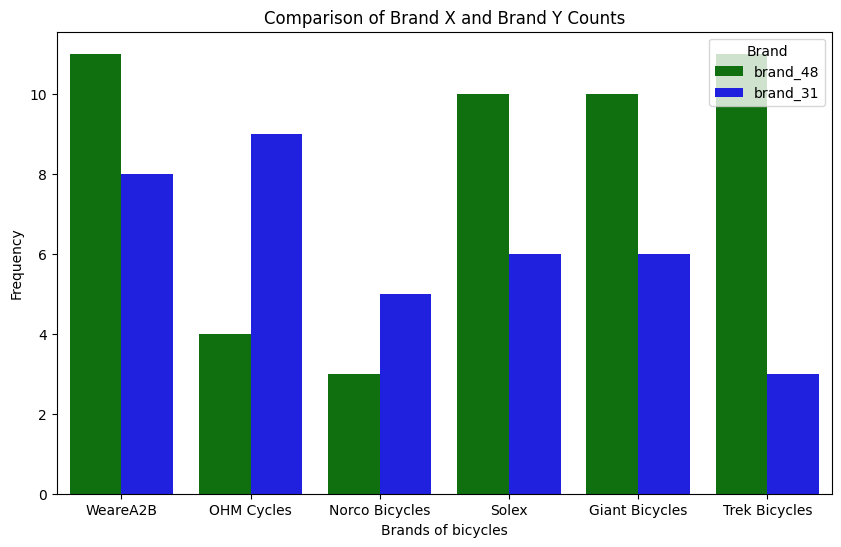

In [ ]:
# brand_48 and brand_31
# Rename column name
df_48_31 = df_48_31.rename(columns={"brand_x": "brand_48", "brand_y": "brand_31"})
data1 = pd.melt(df_48_31, value_vars=['brand_48', 'brand_31'], var_name='Brand', value_name='Count')
# Create a count plot with hue
plt.figure(figsize=(10, 6))
sns.countplot(data=data1, x='Count', hue='Brand', palette=['green', 'blue'])  # You can choose any two distinct colors

plt.title('Comparison of Brand X and Brand Y Counts')
plt.ylabel('Frequency')
plt.xlabel('Brands of bicycles')

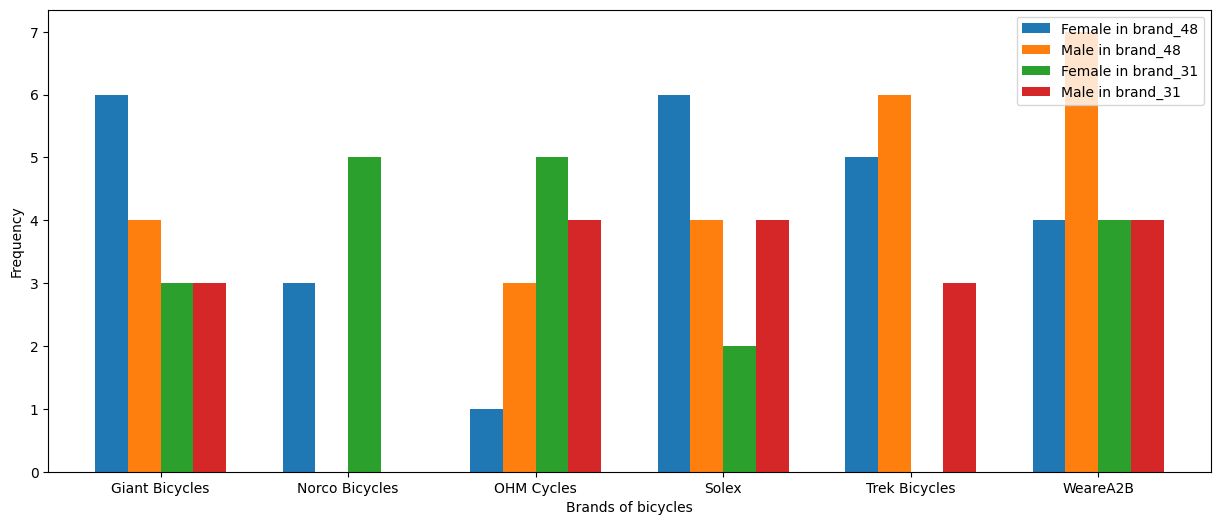

In [ ]:
# brand_48 and brand_31
df_48_31 = df_48_31.rename(columns={"gender_x": "gender_48", "gender_y": "gender_31"})

groupby_48_brand = df_48_31.groupby(['brand_48', 'gender_48']).size().unstack(fill_value=0)
groupby_48_brand = groupby_48_brand.rename(columns={"Female": "Female in brand_48", "Male": "Male in brand_48"}) # rename column name
groupby_31_brand = df_48_31.groupby(['brand_31', 'gender_31']).size().unstack(fill_value=0)
groupby_31_brand = groupby_31_brand.rename(columns={"Female": "Female in brand_31", "Male": "Male in brand_31"})# rename column name
groupby_48_31_brand = pd.concat([groupby_48_brand, groupby_31_brand], axis=1)# concate two new dataframes
groupby_48_31_brand[['Female in brand_48','Male in brand_48','Female in brand_31','Male in brand_31']].plot(kind='bar', width=0.7, figsize=(15, 6))
plt.xticks(rotation=0)
plt.xlabel('Brands of bicycles')
plt.ylabel('Frequency')
plt.show()

Text(0.5, 0, 'Job industry category of customers')

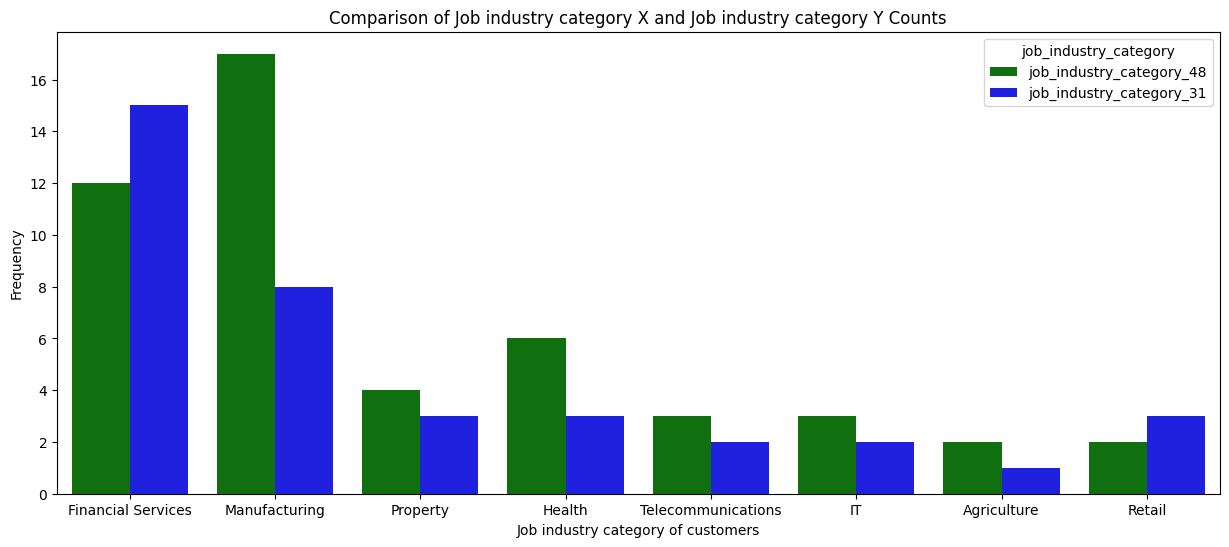

In [ ]:
# job_industry_category_48 and job_industry_category_31
# Rename column name
df_48_31 = df_48_31.rename(columns={"job_industry_category_x": "job_industry_category_48", "job_industry_category_y": "job_industry_category_31"})
data1 = pd.melt(df_48_31, value_vars=['job_industry_category_48', 'job_industry_category_31'], var_name='job_industry_category', value_name='Count')
# Create a count plot with hue
plt.figure(figsize=(15, 6))
sns.countplot(data=data1, x='Count', hue='job_industry_category', palette=['green', 'blue'])  # You can choose any two distinct colors

plt.title('Comparison of Job industry category X and Job industry category Y Counts')
plt.ylabel('Frequency')
plt.xlabel('Job industry category of customers')

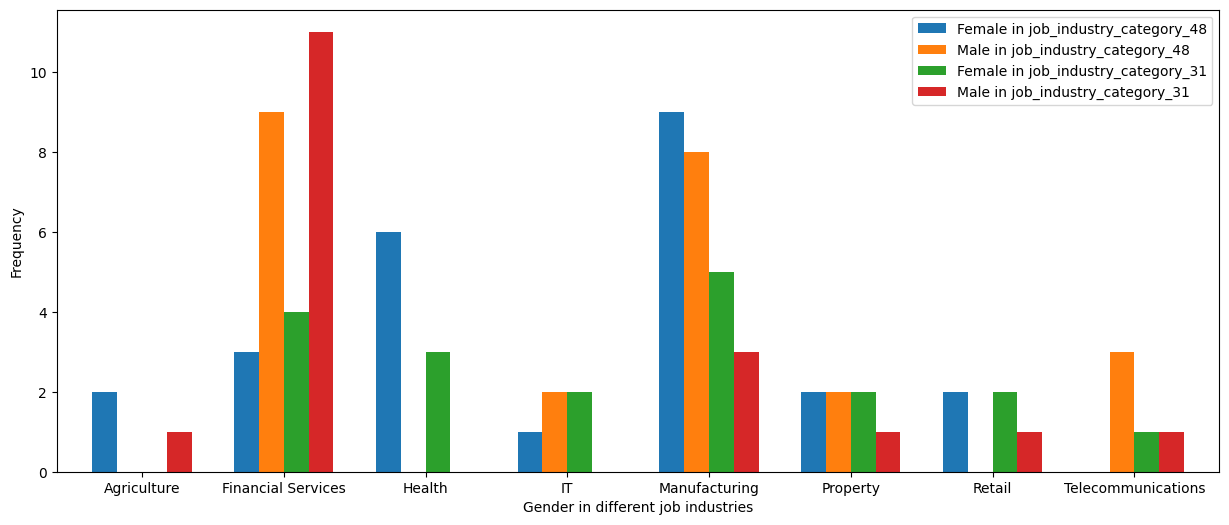

In [ ]:
# job_industry_category_48 and job_industry_category_31，+ gender
groupby_48_jobb = df_48_31.groupby(['job_industry_category_48', 'gender_48']).size().unstack(fill_value=0)
groupby_48_jobb = groupby_48_jobb.rename(columns={"Female": "Female in job_industry_category_48", "Male": "Male in job_industry_category_48"}) # rename column name
groupby_31_jobb = df_48_31.groupby(['job_industry_category_31', 'gender_31']).size().unstack(fill_value=0)
groupby_31_jobb = groupby_31_jobb.rename(columns={"Female": "Female in job_industry_category_31", "Male": "Male in job_industry_category_31"})# rename column name
groupby_48_31_jobb = pd.concat([groupby_48_jobb, groupby_31_jobb], axis=1)# concate two new dataframes
groupby_48_31_jobb[["Female in job_industry_category_48", "Male in job_industry_category_48", "Female in job_industry_category_31", "Male in job_industry_category_31",]].plot(kind='bar', width=0.7, figsize=(15, 6))
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.xlabel('Gender in different job industries')
plt.show()

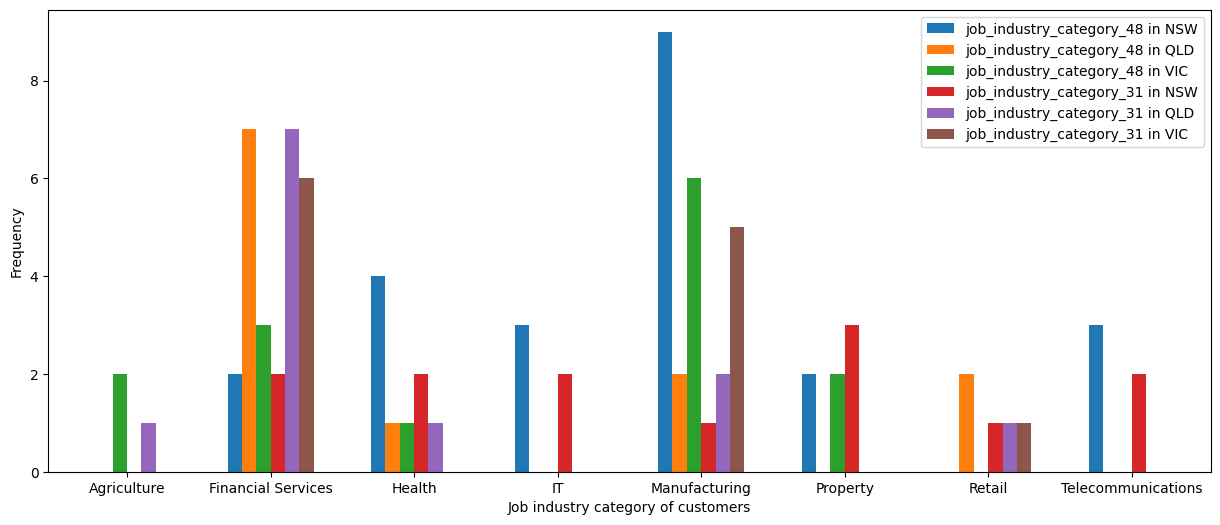

In [ ]:
# job_industry_category_48 and job_industry_category_31，+ state
df_48_31 = df_48_31.rename(columns={"state_x": "state_48", "state_y": "state_31"})

groupby_48_job = df_48_31.groupby(['job_industry_category_48', 'state_48']).size().unstack(fill_value=0)
groupby_48_job = groupby_48_job.rename(columns={"NSW": "job_industry_category_48 in NSW", "QLD": "job_industry_category_48 in QLD",
                                                "VIC": "job_industry_category_48 in VIC"}) # rename column name
groupby_31_job = df_48_31.groupby(['job_industry_category_31', 'state_31']).size().unstack(fill_value=0)
groupby_31_job = groupby_31_job.rename(columns={"NSW": "job_industry_category_31 in NSW", "QLD": "job_industry_category_31 in QLD",
                                                "VIC": "job_industry_category_31 in VIC"})# rename column name
groupby_48_31_job = pd.concat([groupby_48_job, groupby_31_job], axis=1)# concate two new dataframes
groupby_48_31_job[["job_industry_category_48 in NSW", "job_industry_category_48 in QLD", "job_industry_category_48 in VIC", "job_industry_category_31 in NSW",
                   "job_industry_category_31 in QLD", "job_industry_category_31 in VIC"]].plot(kind='bar', width=0.6, figsize=(15, 6))
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.xlabel('Job industry category of customers')
plt.show()

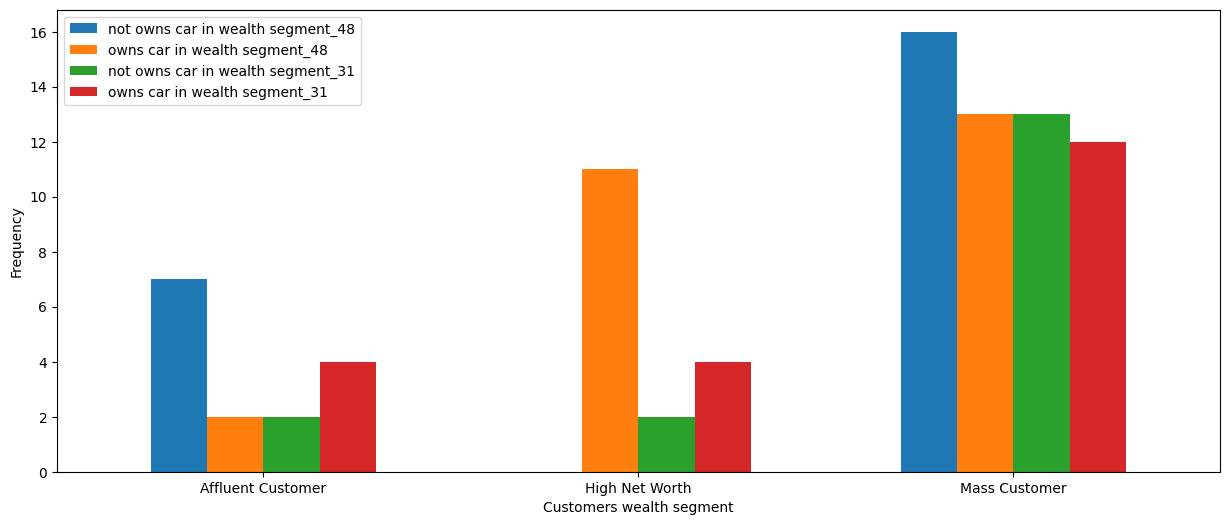

In [ ]:
# wealth_segment_48 and wealth_segment_31，+ owns car
df_48_31 = df_48_31.rename(columns={"wealth_segment_x": "wealth_segment_48", "wealth_segment_y": "wealth_segment_31"})
df_48_31 = df_48_31.rename(columns={"owns_car_x": "owns_car_48", "owns_car_y": "owns_car_31"})

groupby_48_wealth = df_48_31.groupby(['wealth_segment_48', 'owns_car_48']).size().unstack(fill_value=0)
groupby_48_wealth = groupby_48_wealth.rename(columns={"No": "not owns car in wealth segment_48", "Yes": "owns car in wealth segment_48"}) # rename column name

groupby_31_wealth = df_48_31.groupby(['wealth_segment_31', 'owns_car_31']).size().unstack(fill_value=0)
groupby_31_wealth = groupby_31_wealth.rename(columns={"No": "not owns car in wealth segment_31", "Yes": "owns car in wealth segment_31"})# rename column name
groupby_48_31_wealth = pd.concat([groupby_48_wealth, groupby_31_wealth], axis=1)# concate two new dataframes
groupby_48_31_wealth
groupby_48_31_wealth[["not owns car in wealth segment_48", "owns car in wealth segment_48", "not owns car in wealth segment_31",
                      "owns car in wealth segment_31"]].plot(kind='bar', width=0.6, figsize=(15, 6))
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.xlabel('Customers wealth segment')
plt.show()

Text(0.5, 0, 'age group of customers')

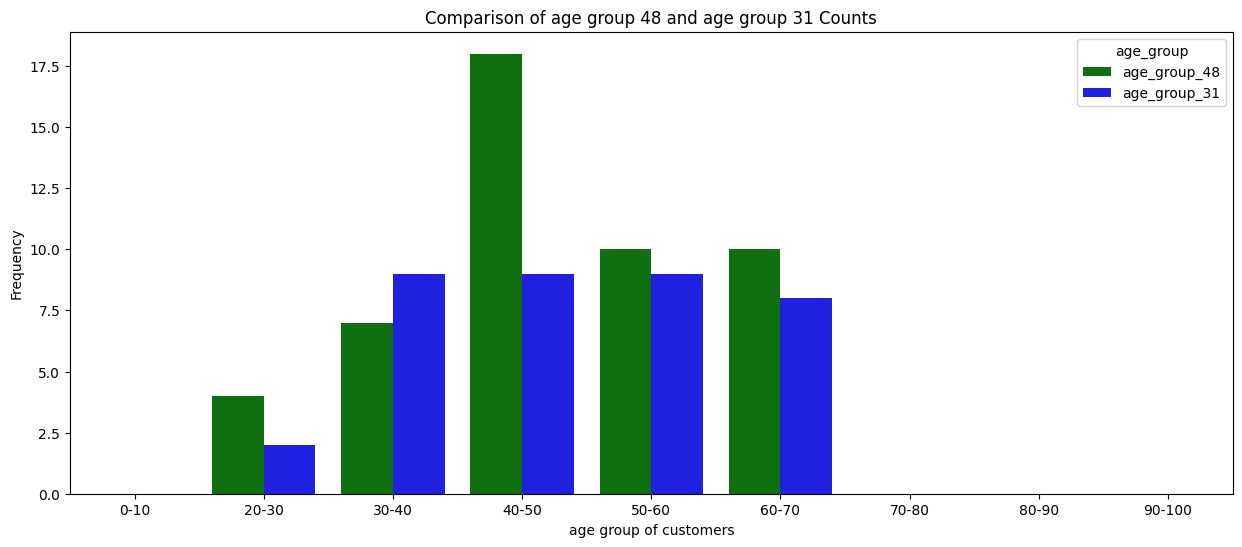

In [ ]:
# Changes by age group
# for 48
df_48_31.loc[df_48_31['age_x'].between(0,10), 'age_group_48'] = '0-10'
df_48_31.loc[df_48_31['age_x'].between(20,30), 'age_group_48'] = '20-30'
df_48_31.loc[df_48_31['age_x'].between(40,50), 'age_group_48'] = '40-50'
df_48_31.loc[df_48_31['age_x'].between(60,70), 'age_group_48'] = '60-70'
df_48_31.loc[df_48_31['age_x'].between(80,90), 'age_group_48'] = '80-90'
df_48_31.loc[df_48_31['age_x'].between(10,20), 'age_group_48'] = '10-20'
df_48_31.loc[df_48_31['age_x'].between(30,40), 'age_group_48'] = '30-40'
df_48_31.loc[df_48_31['age_x'].between(50,60), 'age_group_48'] = '50-60'
df_48_31.loc[df_48_31['age_x'].between(70,80), 'age_group_48'] = '70-80'
df_48_31.loc[df_48_31['age_x'].between(90,100), 'age_group_48'] = '90-100'
# for 31
df_48_31.loc[df_48_31['age_y'].between(0,10), 'age_group_31'] = '0-10'
df_48_31.loc[df_48_31['age_y'].between(20,30), 'age_group_31'] = '20-30'
df_48_31.loc[df_48_31['age_y'].between(40,50), 'age_group_31'] = '40-50'
df_48_31.loc[df_48_31['age_y'].between(60,70), 'age_group_31'] = '60-70'
df_48_31.loc[df_48_31['age_y'].between(80,90), 'age_group_31'] = '80-90'
df_48_31.loc[df_48_31['age_y'].between(10,20), 'age_group_31'] = '10-20'
df_48_31.loc[df_48_31['age_y'].between(30,40), 'age_group_31'] = '30-40'
df_48_31.loc[df_48_31['age_y'].between(50,60), 'age_group_31'] = '50-60'
df_48_31.loc[df_48_31['age_y'].between(70,80), 'age_group_31'] = '70-80'
df_48_31.loc[df_48_31['age_y'].between(90,100), 'age_group_31'] = '90-100'

# barplot for the comparison of age group
data1 = pd.melt(df_48_31, value_vars=['age_group_48', 'age_group_31'], var_name='age_group', value_name='Count')
# Create a count plot with hue
plt.figure(figsize=(15, 6))
age_order = ['0-10', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100']
sns.countplot(data=data1, x='Count', hue='age_group',order=age_order, palette=['green', 'blue'])  # You can choose any two distinct colors

plt.title('Comparison of age group 48 and age group 31 Counts')
plt.ylabel('Frequency')
plt.xlabel('age group of customers')

# RFM analysis

In [ ]:
# rencency: Rank each customer by their most recent transaction
new_data2['RecentDate'] = new_data2.groupby('customer_id')['transaction_date'].transform(max) # add recent date
new_data2['RecencyRank'] = new_data2['RecentDate'].rank(method='dense', ascending=False) # add rank based on RecentDate
# frequency：Rank each customer based on the number of transactions they have made
new_data2['TransactionCount'] = new_data2.groupby('customer_id')['customer_id'].transform('count')
new_data2['FrequencyRank'] = new_data2['TransactionCount'].rank(method='dense', ascending=False)
# monetary: Rank each person based on the amount of profit they contributed
new_data2['profit'] = new_data2['list_price'] - new_data2['standard_cost']
new_data2['CustomerTotalProfit'] = new_data2.groupby('customer_id')['profit'].transform('sum')
new_data2['ProfitRank'] = new_data2['CustomerTotalProfit'].rank(method='dense', ascending=False)
# add total rank column
new_data2['TotalRank'] = new_data2[['RecencyRank', 'FrequencyRank', 'ProfitRank']].mean(axis=1)
new_data2 =new_data2.sort_values(by='TotalRank', ascending=True)
# Add Customer Value Category
new_data2['CustomerValueCategory'] = pd.qcut(new_data2['TotalRank'], 3, labels=['High Value Customer', 'Medium Value Customer', 'Low Value Customer'])
new_data2

<ipython-input-77-1bfc24b061ce>:2: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  new_data2['RecentDate'] = new_data2.groupby('customer_id')['transaction_date'].transform(max) # add recent date


,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,...,property_valuation,RecentDate,RecencyRank,TransactionCount,FrequencyRank,profit,CustomerTotalProfit,ProfitRank,TotalRank,CustomerValueCategory
6825,6826,47,729,2017-08-16,True,Approved,Trek Bicycles,Road,low,small,...,9,2017-12-29,2.0,10,5.0,189.28,10497.78,5.0,4.000000,High Value Customer
1685,1686,68,322,2017-04-03,True,Approved,OHM Cycles,Standard,medium,medium,...,6,2017-12-29,2.0,12,3.0,1592.19,10341.57,7.0,4.000000,High Value Customer
13640,13641,51,322,2017-02-17,False,Approved,OHM Cycles,Standard,high,medium,...,6,2017-12-29,2.0,12,3.0,802.26,10341.57,7.0,4.000000,High Value Customer
5168,5169,81,729,2017-12-01,False,Approved,Norco Bicycles,Standard,medium,small,...,9,2017-12-29,2.0,10,5.0,64.51,10497.78,5.0,4.000000,High Value Customer
16284,16285,19,322,2017-05-10,True,Approved,OHM Cycles,Road,high,large,...,6,2017-12-29,2.0,12,3.0,4.80,10341.57,7.0,4.000000,High Value Customer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15526,15527,60,2525,2017-03-02,False,Approved,Giant Bicycles,Standard,high,small,...,2,2017-03-02,266.0,1,14.0,217.51,217.51,3433.0,1237.666667,Low Value Customer
13825,13826,41,2876,2017-02-08,True,Approved,Norco Bicycles,Standard,low,medium,...,10,2017-02-08,272.0,1,14.0,209.84,209.84,3436.0,1240.666667,Low Value Customer
13976,13977,28,2807,2017-01-11,True,Approved,Norco Bicycles,Standard,medium,small,...,6,2017-01-11,276.0,1,14.0,133.78,133.78,3456.0,1248.666667,Low Value Customer
15435,15436,95,3272,2017-03-10,True,Approved,Giant Bicycles,Standard,medium,large,...,3,2017-03-10,262.0,1,14.0,41.13,41.13,3476.0,1250.666667,Low Value Customer


In [ ]:
df_48_rfm = new_data2[(new_data2['CohortMonth'] == '2017-07-01') & (new_data2['CohortIndex'] == 5)]
df_31_rfm = new_data2[(new_data2['CohortMonth'] == '2017-07-01') & (new_data2['CohortIndex'] == 6)]
df_48_31_rfm = df_48_rfm.merge(df_31_rfm, how ='outer', on = 'customer_id')
df_48_31_rfm

,transaction_id_x,product_id_x,customer_id,transaction_date_x,online_order_x,order_status_x,brand_x,product_line_x,product_class_x,product_size_x,...,property_valuation_y,RecentDate_y,RecencyRank_y,TransactionCount_y,FrequencyRank_y,profit_y,CustomerTotalProfit_y,ProfitRank_y,TotalRank_y,CustomerValueCategory_y
0,19710.0,93.0,45,2017-11-17,True,Approved,WeareA2B,Standard,medium,medium,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10186.0,87.0,119,2017-11-30,True,Approved,OHM Cycles,Standard,medium,medium,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6243.0,9.0,188,2017-11-21,False,Approved,Norco Bicycles,Standard,medium,small,...,11,2017-12-15,16.0,6.0,9.0,139.23,2658.87,1948.0,657.666667,Medium Value Customer
3,6243.0,9.0,188,2017-11-21,False,Approved,Norco Bicycles,Standard,medium,small,...,11,2017-12-15,16.0,6.0,9.0,693.76,2658.87,1948.0,657.666667,Medium Value Customer
4,17493.0,50.0,437,2017-11-12,True,Approved,WeareA2B,Standard,medium,small,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,3992.0,1.0,3172,2017-11-05,False,Approved,Giant Bicycles,Standard,medium,medium,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,NaN,NaN,3203,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,8,2017-12-23,8.0,3.0,12.0,217.51,1744.21,2727.0,915.666667,Low Value Customer
65,17715.0,67.0,3211,2017-11-25,True,Approved,Solex,Standard,medium,large,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,7407.0,91.0,3378,2017-11-05,False,Approved,Solex,Standard,medium,medium,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 0, 'Customer Value Category')

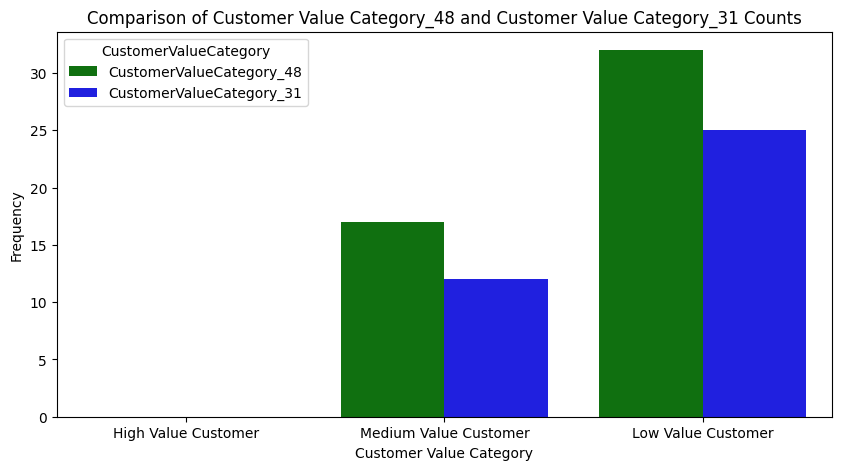

In [ ]:
#CustomerValueCategory_48 and CustomerValueCategory_31
# Rename column name
df_48_31_rfm = df_48_31_rfm.rename(columns={"CustomerValueCategory_x": "CustomerValueCategory_48", "CustomerValueCategory_y": "CustomerValueCategory_31"})
data1_rfm = pd.melt(df_48_31_rfm, value_vars=['CustomerValueCategory_48', 'CustomerValueCategory_31'], var_name='CustomerValueCategory', value_name='Count')
data1_rfm
# Create a count plot with hue
plt.figure(figsize=(10, 5))
sns.countplot(data=data1_rfm, x='Count', hue='CustomerValueCategory', palette=['green', 'blue'])  # You can choose any two distinct colors

plt.title('Comparison of Customer Value Category_48 and Customer Value Category_31 Counts')
plt.ylabel('Frequency')
plt.xlabel('Customer Value Category')

<ipython-input-80-38daa1f7dcf0>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby_48_brand_rfm = df_48_31_rfm.groupby(['brand_48', 'CustomerValueCategory_48']).size().unstack(fill_value=0)
<ipython-input-80-38daa1f7dcf0>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby_31_brand_rfm = df_48_31_rfm.groupby(['brand_31', 'CustomerValueCategory_31']).size().unstack(fill_value=0)


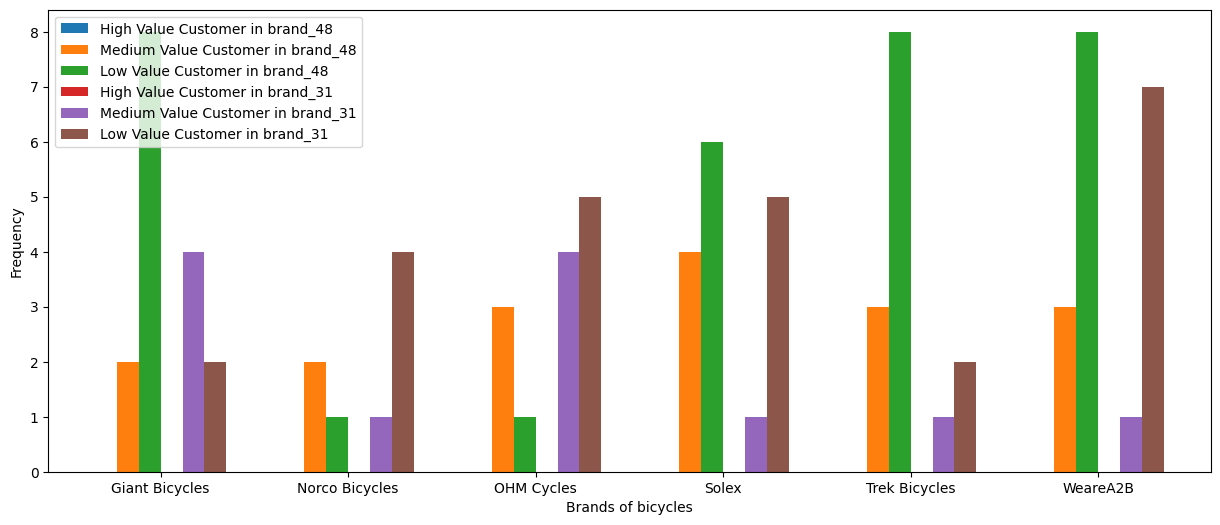

In [ ]:
# see which bicycle brands customers with different values prefer
# brand_48 and brand_31
# rename column
df_48_31_rfm = df_48_31_rfm.rename(columns={"brand_x": "brand_48", "brand_y": "brand_31"})
groupby_48_brand_rfm = df_48_31_rfm.groupby(['brand_48', 'CustomerValueCategory_48']).size().unstack(fill_value=0)
groupby_48_brand_rfm = groupby_48_brand_rfm.rename(columns={"High Value Customer": "High Value Customer in brand_48", "Medium Value Customer": "Medium Value Customer in brand_48",
                                                            "Low Value Customer": "Low Value Customer in brand_48"}) # rename column name
groupby_31_brand_rfm = df_48_31_rfm.groupby(['brand_31', 'CustomerValueCategory_31']).size().unstack(fill_value=0)
groupby_31_brand_rfm = groupby_31_brand_rfm.rename(columns={"High Value Customer": "High Value Customer in brand_31", "Medium Value Customer": "Medium Value Customer in brand_31",
                                                            "Low Value Customer": "Low Value Customer in brand_31"}) # rename column name
groupby_48_31_brand_rfm = pd.concat([groupby_48_brand_rfm, groupby_31_brand_rfm], axis=1)# concate two new dataframes
groupby_48_31_brand_rfm[["High Value Customer in brand_48", "Medium Value Customer in brand_48", "Low Value Customer in brand_48", "High Value Customer in brand_31",
                         "Medium Value Customer in brand_31", "Low Value Customer in brand_31"]].plot(kind='bar', width=0.7, figsize=(15, 6))
plt.xticks(rotation=0)
plt.xlabel('Brands of bicycles')
plt.ylabel('Frequency')
plt.show()

<ipython-input-81-f21fca300fca>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby_48_product_class_rfm = df_48_31_rfm.groupby(['product_class_48', 'CustomerValueCategory_48']).size().unstack(fill_value=0)
<ipython-input-81-f21fca300fca>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby_31_product_class_rfm = df_48_31_rfm.groupby(['product_class_31', 'CustomerValueCategory_31']).size().unstack(fill_value=0)


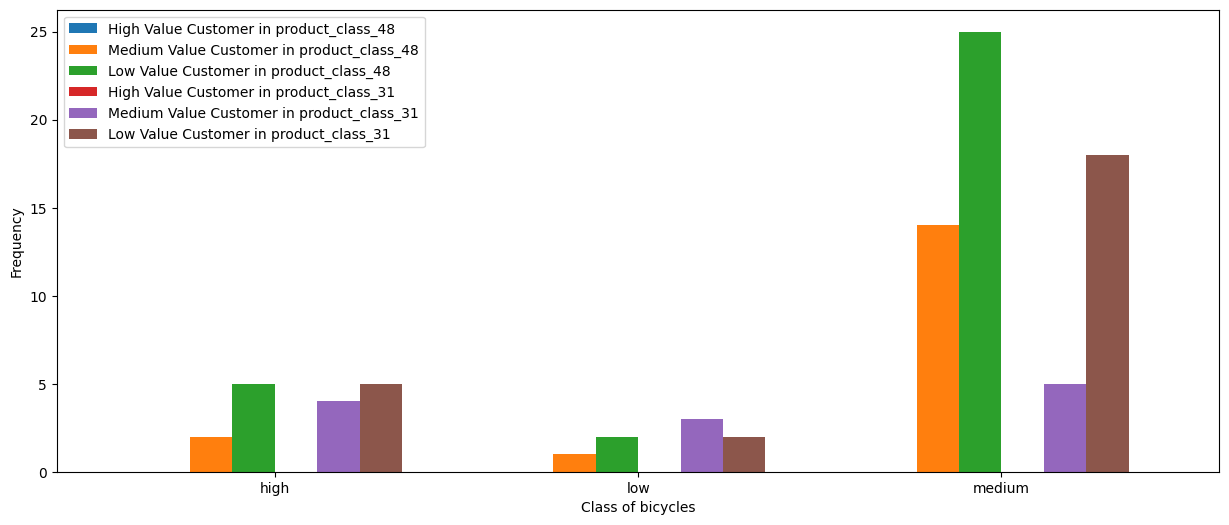

In [ ]:
# see which bicycle class customers with different values prefer
# product_class_48 and product_class_31
# rename column
df_48_31_rfm = df_48_31_rfm.rename(columns={"product_class_x": "product_class_48", "product_class_y": "product_class_31"})
groupby_48_product_class_rfm = df_48_31_rfm.groupby(['product_class_48', 'CustomerValueCategory_48']).size().unstack(fill_value=0)
groupby_48_product_class_rfm = groupby_48_product_class_rfm.rename(columns={"High Value Customer": "High Value Customer in product_class_48", "Medium Value Customer": "Medium Value Customer in product_class_48",
                                                             "Low Value Customer": "Low Value Customer in product_class_48"}) # rename column name
groupby_31_product_class_rfm = df_48_31_rfm.groupby(['product_class_31', 'CustomerValueCategory_31']).size().unstack(fill_value=0)
groupby_31_product_class_rfm = groupby_31_product_class_rfm.rename(columns={"High Value Customer": "High Value Customer in product_class_31", "Medium Value Customer": "Medium Value Customer in product_class_31",
                                                             "Low Value Customer": "Low Value Customer in product_class_31"}) # rename column name
groupby_48_31_product_class_rfm = pd.concat([groupby_48_product_class_rfm, groupby_31_product_class_rfm], axis=1)# concate two new dataframes
groupby_48_31_product_class_rfm[["High Value Customer in product_class_48", "Medium Value Customer in product_class_48", "Low Value Customer in product_class_48", "High Value Customer in product_class_31",
                          "Medium Value Customer in product_class_31", "Low Value Customer in product_class_31"]].plot(kind='bar', width=0.7, figsize=(15, 6))
plt.xticks(rotation=0)
plt.xlabel('Class of bicycles')
plt.ylabel('Frequency')
plt.show()


<ipython-input-82-08d14fd8792b>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby_48_product_size_rfm = df_48_31_rfm.groupby(['product_size_48', 'CustomerValueCategory_48']).size().unstack(fill_value=0)
<ipython-input-82-08d14fd8792b>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby_31_product_size_rfm = df_48_31_rfm.groupby(['product_size_31', 'CustomerValueCategory_31']).size().unstack(fill_value=0)


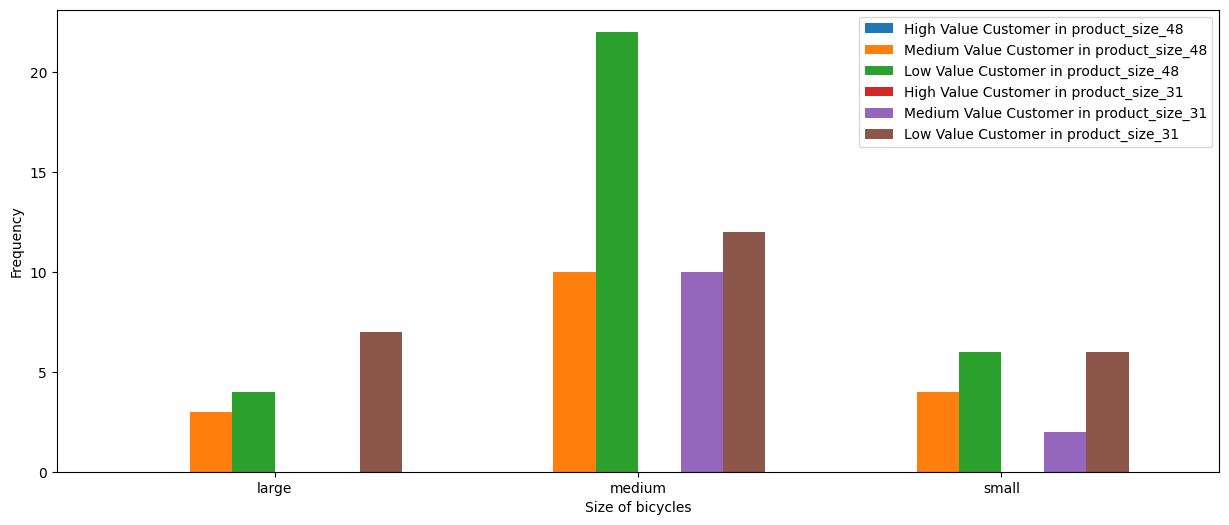

In [ ]:
# see which bicycle size customers with different values prefer
# product_size_48 and product_size_31
# rename column
df_48_31_rfm = df_48_31_rfm.rename(columns={"product_size_x": "product_size_48", "product_size_y": "product_size_31"})
groupby_48_product_size_rfm = df_48_31_rfm.groupby(['product_size_48', 'CustomerValueCategory_48']).size().unstack(fill_value=0)
groupby_48_product_size_rfm = groupby_48_product_size_rfm.rename(columns={"High Value Customer": "High Value Customer in product_size_48", "Medium Value Customer": "Medium Value Customer in product_size_48",
                                                             "Low Value Customer": "Low Value Customer in product_size_48"}) # rename column name
groupby_31_product_size_rfm = df_48_31_rfm.groupby(['product_size_31', 'CustomerValueCategory_31']).size().unstack(fill_value=0)
groupby_31_product_size_rfm = groupby_31_product_size_rfm.rename(columns={"High Value Customer": "High Value Customer in product_size_31", "Medium Value Customer": "Medium Value Customer in product_size_31",
                                                             "Low Value Customer": "Low Value Customer in product_size_31"}) # rename column name
groupby_48_31_product_size_rfm = pd.concat([groupby_48_product_size_rfm, groupby_31_product_size_rfm], axis=1)# concate two new dataframes
groupby_48_31_product_size_rfm[["High Value Customer in product_size_48", "Medium Value Customer in product_size_48", "Low Value Customer in product_size_48", "High Value Customer in product_size_31",
                          "Medium Value Customer in product_size_31", "Low Value Customer in product_size_31"]].plot(kind='bar', width=0.7, figsize=(15, 6))
plt.xticks(rotation=0)
plt.xlabel('Size of bicycles')
plt.ylabel('Frequency')
plt.show()
